# Miniproyecto 2 — El Transformer, pieza por pieza

## Clasificación de polaridad en reseñas turísticas en español (Rest-Mex 2025)

Maestría · Universidad Icesi · Curso de Procesamiento de Lenguaje Natural

Autores: Juan José Aguado · Juan David Cruz · Juan Diego Ramírez

---

> **Sobre la reutilización del corpus.** Este notebook trabaja sobre el mismo corpus del
> Miniproyecto 1 y reproduce su análisis exploratorio **íntegro y sin modificar**, con
> autorización explícita del profesor y bajo la condición de que el notebook sea
> autosuficiente: se puede leer y ejecutar de principio a fin sin abrir la entrega anterior.
>
> Lo nuevo empieza en la Sección 4. Allí cambiamos de técnica: implementamos el
> **Transformer en su forma original** —codificador con atención multi-cabeza, *positional
> encoding* sinusoidal, conexiones residuales y normalización por capa— sin usar
> `nn.Transformer`, `nn.TransformerEncoderLayer` ni `nn.MultiheadAttention`, y lo comparamos
> contra un **MLP simple** y contra los modelos del Miniproyecto 1.

## 0. El problema

Dada una reseña turística escrita en español por un visitante sobre un destino mexicano,
predecir la polaridad (1 a 5 estrellas) que le asignó su autor, usando únicamente el texto.

El problema, el corpus y el análisis exploratorio son los del Miniproyecto 1. Lo que cambia
es la técnica, y con ella la pregunta:

> **¿Qué aporta realmente la atención sobre esta tarea, y a qué costo?**

Para responderla comparamos, sobre el mismo split y las mismas métricas:

1. **Un MLP simple** — bolsa de palabras hacia capas densas. No tiene ninguna noción de
   orden: para él «no está mal» y «está mal, no» son el mismo vector. Es el punto de
   referencia que exige la rúbrica y el que hace visible qué añade el Transformer.
2. **Un Transformer *encoder* implementado desde cero**, fiel al paper original
   (*Attention Is All You Need*, Vaswani et al. 2017). El producto punto escalado, la
   separación en cabezas, la máscara de padding y las conexiones residuales se escriben a
   mano, porque el objetivo es entender la arquitectura por dentro, no invocarla.
3. **Los modelos del Miniproyecto 1** — TF-IDF + Regresión Logística, LSTM desde cero y
   BiLSTM con embeddings de spaCy — para situar la atención en la escalera completa de
   representaciones del curso.

Hay una razón concreta para esperar que la atención ayude en *esta* tarea, y sale del EDA
de la Sección 3: en las reseñas de 1★ el rasgo dominante es la **negación** (3,75 negaciones
por cada 100 palabras, frente a 1,11 en las de 5★). Un modelo sin orden no puede distinguir
«no lo recomiendo» de «lo recomiendo»; uno con atención puede, en principio, aprender a
ligar el «no» con el verbo al que afecta.

De ahí salen las dos hipótesis que el notebook pone a prueba:

> **H1.** El Transformer superará al MLP sobre todo en las clases negativas, donde la
> negación es el rasgo distintivo.
>
> **H2 (control).** Si se elimina la señal posicional, el Transformer debería caer hacia el
> nivel del MLP. Si no cae, su ventaja —si la hay— no viene de usar el orden.

### Mapa del notebook

| Sección | Contenido |
|---|---|
| 1 | Entorno, reproducibilidad y configuración adaptativa |
| 2 | El corpus: Rest-Mex 2025 · *heredado del Miniproyecto 1* |
| 3 | **Análisis exploratorio (EDA)** · *heredado del Miniproyecto 1, sin modificar* |
| 4 | Preprocesamiento y protocolo: tokenizador y vocabulario **heredados del Miniproyecto 1**, submuestra, Split A, métricas |
| 5 | **Modelo A** — MLP sobre embeddings promediados (enmascarados) |
| 6 | **Modelo B** — Transformer *encoder* desde cero, pieza por pieza (vocabulario por palabras) |
| 7 | Comparación MLP vs. Transformer |
| 8 | Ablaciones estructurales, incluida **BPE vs. palabras** como variante de preprocesamiento |
| 9 | Más allá del paper: Pre-LN, `[CLS]`, *label smoothing* |
| 10 | Barrido de hiperparámetros |
| 11 | El costo cuadrático de la atención, medido |
| 12 | Tarea de control: la misma arquitectura prediciendo `Type` |
| 13 | Comparación contra los modelos del Miniproyecto 1 (con el vocabulario compartido) |
| 14 | ¿En qué se fija el Transformer? Atención e interpretabilidad |
| 15 | Demo interactiva |
| 16 | Análisis de errores |
| 17 | Conclusiones y limitaciones |

Las secciones 1 a 3 son el contexto compartido con la entrega anterior; el trabajo propio de
este miniproyecto está en las secciones 4 a 17.

---

## 1. Entorno y reproducibilidad

Antes de cualquier análisis fijamos las condiciones que hacen que este notebook produzca los
mismos números en cada ejecución, y que corra igual en Colab con GPU, en Colab sin GPU y en
una máquina local.

Esto pesa más aquí que en la entrega anterior. Vamos a afirmar cosas como «las conexiones
residuales suben el macro-F1 en tantos puntos» o «el Transformer cuesta *n* veces más que
TF-IDF»: afirmaciones que solo significan algo si todas las corridas comparten semilla,
split y hardware. Las Secciones 8 a 11 son, literalmente, comparaciones entre corridas que
difieren en una sola cosa; sin control de la aleatoriedad no medirían nada.

In [1]:
import sys, os, warnings

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Ejecutando en Colab: {IN_COLAB}')
print(f'Python: {sys.version.split()[0]}')

Ejecutando en Colab: False
Python: 3.14.4


Instalamos únicamente lo que falte. En Colab casi todo viene preinstalado.

Dos notas sobre las dependencias de esta entrega:

- **`transformers` y `tokenizers`** se usan *solo* para la variante BPE de preprocesamiento
  (§8/§9, D-216), no para el modelo base: el vocabulario del Transformer que alimenta la
  comparación principal (§13) es el mismo por-palabras del Miniproyecto 1 (D-214). Ninguna
  capa del modelo sale de esas librerías: cada capa se implementa a mano en la Sección 6.
- **Los vectores de spaCy (~570 MB)** ya no alimentan ningún modelo aquí; se necesitan
  únicamente para reproducir el análisis de cobertura de vocabulario del EDA (§3.7), que se
  conserva intacto por la condición del profesor.

In [2]:
import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU")

x = torch.randn(3, 3, device="cuda" if torch.cuda.is_available() else "cpu")
print("prueba tensor OK:", (x @ x).shape)

torch: 2.14.0+cu130 | CUDA: True | NVIDIA GeForce RTX 3050 6GB Laptop GPU
prueba tensor OK: torch.Size([3, 3])


In [ ]:
# =========================================================================
# 1 · Entorno y reproducibilidad
# =========================================================================
import sys, os, platform, random, warnings, time
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# --- ¿Estamos en Colab? ---
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# --- Vectores de spaCy: solo para el EDA §3.7 (cobertura de vocabulario) ---
import spacy
if not spacy.util.is_package("es_core_news_lg"):
    print("Descargando es_core_news_lg (~570 MB, 1-2 min)...")
    os.system(f"{sys.executable} -m spacy download es_core_news_lg")
    print("Descarga terminada.")

# --- ftfy: corrección de mojibake en el EDA §3.1 ---
try:
    import ftfy  # noqa: F401
except ImportError:
    os.system(f"{sys.executable} -m pip install -q ftfy")

# --- tokenizers/transformers: SOLO para la variante BPE de §8/§9 (D-216).
#     El modelo base usa el vocabulario por palabras heredado de MP1 (§4).
try:
    import transformers, tokenizers  # noqa: F401
except ImportError:
    os.system(f"{sys.executable} -m pip install -q transformers tokenizers")


### Semilla global

Fijamos `SEED = 42` en todas las fuentes de aleatoriedad del pipeline: submuestreo,
particiones, inicialización de pesos y orden de los lotes.

In [4]:
# --- Semilla global ---
import numpy as np
import torch

SEED = 42

def fijar_semilla(sem: int = SEED):
    """Fija la semilla en random, numpy y torch (incl. CUDA)."""
    random.seed(sem)
    np.random.seed(sem)
    torch.manual_seed(sem)
    torch.cuda.manual_seed_all(sem)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fijar_semilla()
G = torch.Generator().manual_seed(SEED)   # barajado reproducible de los DataLoader

fijar_semilla()
print("\nSemilla global fijada en", SEED)


Semilla global fijada en 42


### Configuración adaptativa

El notebook debe correr en cualquier entorno, no fallar en el que no tenga GPU. Esta celda
detecta el dispositivo y ajusta tamaños de lote, número de épocas y estrategia para el
transformer. La configuración activa se imprime para que quede registrada junto a los
resultados.

In [ ]:
# --- Dispositivo y configuración adaptativa ---
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAY_GPU = DISPOSITIVO.type == "cuda"

# Presupuesto: el notebook completo debe caber en ~30 min con GPU. Sin GPU se degrada
# (submuestra menor, menos épocas, modelo más pequeño) pero NUNCA falla.
if HAY_GPU:
    CFG = dict(submuestra=40_000, epocas=10, batch=64,
               max_vocab=30_000, vocab_bpe=20_000, emb_dim=128, hidden=128,
               num_heads=8, num_bloques=2, ff_dim=256, dropout=0.1)
    # Configuración reducida para los estudios de las §8-§11 (muchas corridas).
    CFG_ABL = dict(epocas=5, num_bloques=2, emb_dim=128)
else:
    CFG = dict(submuestra=12_000, epocas=5, batch=32,
               max_vocab=25_000, vocab_bpe=12_000, emb_dim=96, hidden=96,
               num_heads=6, num_bloques=1, ff_dim=192, dropout=0.1)
    CFG_ABL = dict(epocas=3, num_bloques=1, emb_dim=96)

# lr 3e-4 con warmup: el notebook guía usa 2e-5, que es una tasa de *fine-tuning* de un
# modelo preentrenado; para entrenar un Transformer desde cero es demasiado baja y el
# modelo apenas se mueve. Ver docs/DECISIONS.md §D-204.
CFG.update(lr=3e-4, warmup_frac=0.10, label_smoothing=0.1, paciencia=3, seed=SEED)
assert CFG["emb_dim"] % CFG["num_heads"] == 0, "emb_dim debe ser divisible por num_heads"

# --- Traza del entorno (queda registrada en el .ipynb) ---
import sklearn, pandas as pd
try:
    import datasets
    ver_ds = datasets.__version__
except Exception:
    ver_ds = "no instalado"

print("Python      :", sys.version.split()[0], "| SO:", platform.system())
print("¿En Colab?  :", EN_COLAB)
print("Dispositivo :", DISPOSITIVO,
      f"({torch.cuda.get_device_name(0)})" if HAY_GPU else "")
print("Versiones   : torch", torch.__version__, "| sklearn", sklearn.__version__,
      "| pandas", pd.__version__, "| spacy", spacy.__version__, "| datasets", ver_ds)
print("\nCFG activa  :")
for k, v in CFG.items():
    print(f"  {k:16s}: {v}")


---

> ### Nota sobre las Secciones 2 y 3
>
> Todo lo que sigue hasta el final de la Sección 3 está **copiado sin modificar** del
> notebook del Miniproyecto 1: mismo código, mismas gráficas, mismas lecturas. Se reproduce
> íntegro por indicación del profesor, para que esta entrega sea autosuficiente y se pueda
> evaluar sin abrir la anterior.
>
> Eso implica que sus lecturas están escritas en los términos de aquel trabajo: hablan del
> «modelo 3», de la LSTM o de secciones que aquí tienen otro número. **No es un descuido**:
> alterar el texto habría significado no entregar el mismo EDA. Al cerrar la Sección 3 hay
> una celda puente que retraduce cada hallazgo a las decisiones de *esta* entrega.
>
> Si ya leíste el Miniproyecto 1, puedes saltar directamente a la **Sección 4**.

---

## 2. El corpus

Trabajamos con [`vg055/Rest-Mex2025`](https://huggingface.co/datasets/vg055/Rest-Mex2025):
208,051 reseñas turísticas en español sobre destinos de México, del shared task
**Rest-Mex 2025** de IberLEF. Licencia CC-BY-4.0.

**Por qué este corpus.** Rest-Mex 2025 además del texto y la polaridad (1–5), trae el pueblo, la región y el tipo de
establecimiento. Eso nos da tres cosas que otros corpus de sentimiento en español no ofrecen
a la vez: una **variable objetivo ordinal**, un **desbalance de clases real** (no fabricado)
y un **eje geográfico** con el que montar una prueba de generalización.

**Entrada de los modelos.** Concatenamos `Title` + `Review`. El título suele ser la señal
más condensada de la reseña («Todo excelente», «Nunca más»), y descartarlo sería desperdiciar información.

In [6]:
# =========================================================================
# 2 · Carga del corpus Rest-Mex 2025
# =========================================================================
from datasets import load_dataset
from datetime import date

t0 = time.time()
ds = load_dataset("vg055/Rest-Mex2025", split="train")
df = ds.to_pandas()
print(f"Descarga + to_pandas: {time.time() - t0:.1f} s  |  fecha de descarga: {date.today().isoformat()}")

# --- Normalización mínima ---
df["Polarity"] = df["Polarity"].astype(int)
df["Title"]  = df["Title"].fillna("").astype(str).str.strip()
df["Review"] = df["Review"].fillna("").astype(str).str.strip()
df["texto"]  = (df["Title"] + ". " + df["Review"]).str.strip()   # entrada única de todos los modelos

# --- Inspección inicial ---
print("\nShape:", df.shape)
print("\nDtypes:")
print(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].dtypes.to_string())
display(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].head())

# --- Verificación contra docs/DATASET.md §3 (si no coincide, el corpus cambió en el Hub) ---
print("\n--- Verificación ---")
print(f"Registros          : {len(df):>8,}     (DATASET.md: 208,051)")
print(f"Regiones / Pueblos : {df['Region'].nunique():>3} / {df['Town'].nunique():<3}   (DATASET.md: 19 / 40)")
print(f"Tipos              : {sorted(df['Type'].unique())}")
print(f"Rango de Polarity  : {df['Polarity'].min()} - {df['Polarity'].max()}")
print("\nDistribución de Polarity (%):")
print((df["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2).to_string())
print("\nDistribución de Type (%):")
print((df["Type"].value_counts(normalize=True) * 100).round(2).to_string())
print("\nNulos por columna:")
print(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].isna().sum().to_string())

Descarga + to_pandas: 3.6 s  |  fecha de descarga: 2026-09-09

Shape: (208051, 7)

Dtypes:
Title         str
Review        str
Polarity    int64
Town          str
Region        str
Type          str


,Title,Review,Polarity,Town,Region,Type
0,Mi Lugar Favorito!!!!,Excelente lugar para comer y pasar una buena n...,5,Sayulita,Nayarit,Restaurant
1,lugares interesantes para visitar,"andar mucho, así que un poco difícil para pers...",4,Tulum,QuintanaRoo,Attractive
2,No es el mismo Dreams,"Es nuestra cuarta visita a Dreams Tulum, elegi...",3,Tulum,QuintanaRoo,Hotel
3,un buen panorama cerca de CancÃºn,"Estando en CancÃºn, fuimos al puerto y tomamos...",4,Isla_Mujeres,QuintanaRoo,Attractive
4,El mejor,Es un lugar antiguo y por eso me encanto tiene...,5,Patzcuaro,Michoacan,Hotel



--- Verificación ---
Registros          :  208,051     (DATASET.md: 208,051)
Regiones / Pueblos :  19 / 40    (DATASET.md: 19 / 40)
Tipos              : ['Attractive', 'Hotel', 'Restaurant']
Rango de Polarity  : 1 - 5

Distribución de Polarity (%):
Polarity
1     2.62
2     2.64
3     7.46
4    21.65
5    65.64

Distribución de Type (%):
Type
Restaurant    41.68
Attractive    33.61
Hotel         24.71

Nulos por columna:
Title       0
Review      0
Polarity    0
Town        0
Region      0
Type        0


Antes de cualquier estadística, conviene ver el material crudo. Estas tres reseñas (una negativa, una intermedia y una positiva) dan la medida del registro, la extensión y el tipo
de lenguaje al que nos enfrentamos.

In [7]:
# --- Tres reseñas crudas, una por nivel de polaridad ---
fijar_semilla()
for estrellas in (1, 3, 5):
    r = df[df["Polarity"] == estrellas].sample(1, random_state=SEED).iloc[0]
    print("=" * 100)
    print(f"[{estrellas}★]   Región: {r['Region']}   |   Pueblo: {r['Town']}   |   Tipo: {r['Type']}")
    print(f"Título : {r['Title']}")
    cuerpo = r["Review"]
    print(f"Reseña : {cuerpo[:800]}{'...' if len(cuerpo) > 800 else ''}")
    print(f"(longitud real del cuerpo: {len(cuerpo)} caracteres)\n")

[1★]   Región: QuintanaRoo   |   Pueblo: Isla_Mujeres   |   Tipo: Restaurant
Título : La peor experiencia de mi vida
Reseña : Como mexicano, es mi deber de alerta turistas acerca de este lugar. El domingo pasado mi mujer quería comer allí. Hicimos la reserva por teléfono. Como cortesía, ofrecen transporte que te lleva desde/hasta Cancún. Les pedimos que en el lugar de recogida 15 minutos salida...previa. Nos hicieron todo lo que pedimos. Nunca llegó. ( ? !) Cuando llamamos para pedir lo que estaba ocurriendo, sólo decir: "El barco marchamos antes, lo siento".  No aceptamos que una explicación, así que nos exigieron a hablar con el gerente. Se negaron a hagámoslo. Después de varios minutos en el teléfono, que ofrecen para enviar de barco nuevo. En 20 minutos estará allí, dijeron. Pensamos que la solución era satisfactoria. Pero ... lo creas o no el barco nunca llegó. Nos llamar, de nuevo, y que, de nuevo, limitado...
(longitud real del cuerpo: 1050 caracteres)

[3★]   Región: Guerrero  

Lo que se observa en el material crudo:

- **Registro coloquial y reseñas multi-tema.** Una misma reseña cubre reserva, transporte,
  trato y comida (1★) o comida, vino, ubicación y organización (5★). El modelo debe integrar
  señales dispersas, no clasificar una sola frase.
- **La reseña de 3★ es explícitamente mixta:** «gran vista» / «la comida no es buena» /
  «la cerveza es barata». Elogio y queja conviven. Anticipamos que 3★ será la clase más
  difícil, y aquí se ve por qué.
- **Ruido de codificación:** *CancÃºn* en vez de *Cancún*, mojibake por doble codificación
  UTF-8/Latin-1 en el CSV de origen.
- **Marcadores de truncamiento de TripAdvisor:** reseñas que terminan en «...Más» o «….Más»,
  restos del botón «leer más». Ruido a limpiar antes de tokenizar.
- **Texto a veces poco natural** («El barco marchamos antes, lo siento»): parte del corpus
  está traducido automáticamente o escrito por hablantes no nativos. Es dificultad inherente
  a los datos, no del modelo.

<!-- REDACTAR: qué se observa en los ejemplos. Registro coloquial, mezcla de temas dentro
     de una misma reseña, anglicismos, uso de mayúsculas y signos. Anticipar aquí que la
     reseña de 3 estrellas probablemente contenga elogios y quejas mezclados: eso explicará
     buena parte de los errores de la sección 14. -->

---

## 3. Análisis exploratorio

Esta sección no es un requisito administrativo: de aquí salen cuatro decisiones concretas
la métrica principal, la longitud máxima de secuencia, el diseño de la partición
geográfica y el tratamiento de la ordinalidad, y todas quedan justificadas con datos en
§3.8.

El análisis se hace sobre **el corpus completo** (208k). Solo el entrenamiento usará una
submuestra.

### 3.1 Calidad de los datos

Los nulos ya sabemos que son cero. Aquí buscamos lo que sí puede
contaminar el análisis y el entrenamiento: **duplicados exactos** (la misma reseña repetida
caería a la vez en train y test, es decir data-leakage), reseñas demasiado cortas para contener sentimiento, y dos defectos de origen que ya vimos en crudo: el **mojibake** de codificación y los **marcadores `...Más`** de TripAdvisor.

Diagnosticamos primero, decidimos después, y aplicamos solo la limpieza que se pueda
justificar.

In [8]:
# =========================================================================
# 3.1 · Diagnóstico de calidad
# =========================================================================
import re

def tiene_mojibake(s: str) -> bool:
    return ("Ã" in s) or ("Â¿" in s) or ("Â¡" in s) or ("Âº" in s)

_pat_mas = re.compile(r"(?:\.{2,}|…)\s*Más\s*$")

rep = {
    "registros"                     : len(df),
    "Title vacío"                   : int((df["Title"] == "").sum()),
    "Review vacío"                  : int((df["Review"] == "").sum()),
    "Review < 15 caracteres"        : int((df["Review"].str.len() < 15).sum()),
    "duplicados exactos de 'texto'" : int(df["texto"].duplicated().sum()),
    "duplicados (texto, Polarity)"  : int(df.duplicated(["texto", "Polarity"]).sum()),
    "texto con mojibake"            : int(df["texto"].map(tiene_mojibake).sum()),
    "Review termina en '...Más'"    : int(df["Review"].str.contains(_pat_mas).sum()),
    "Polarity fuera de 1..5"        : int((~df["Polarity"].between(1, 5)).sum()),
}
display(pd.DataFrame({"chequeo": list(rep), "valor": list(rep.values())}))

print("\nEjemplos de mojibake (Title):")
for s in df.loc[df["texto"].map(tiene_mojibake), "Title"].head(5).tolist():
    print("  ", repr(s))

print("\nEjemplos de reseñas muy cortas:")
for s in df.loc[df["Review"].str.len() < 15, "Review"].head(5).tolist():
    print("  ", repr(s))

if rep["duplicados exactos de 'texto'"]:
    d = df[df["texto"].duplicated(keep=False)].sort_values("texto")
    print("\nEjemplo de par duplicado:")
    for _, r in d.head(2).iterrows():
        print(f"  [{r['Polarity']}★] {r['texto'][:130]}")

,chequeo,valor
0,registros,208051
1,Title vacío,6
2,Review vacío,0
3,Review < 15 caracteres,0
4,duplicados exactos de 'texto',182
5,"duplicados (texto, Polarity)",182
6,texto con mojibake,4885
7,Review termina en '...Más',16248
8,Polarity fuera de 1..5,0



Ejemplos de mojibake (Title):


   'un buen panorama cerca de CancÃºn'
   'Gran labor del Gerente despuÃ©s de 5 aÃ±os.'
   'Playa hermosa!'
   'FÃ¡cil acceso pÃºblico'
   'Inigualable'

Ejemplos de reseñas muy cortas:

Ejemplo de par duplicado:
  [5★] A debe parar!. Tuvimos la suerte de visitar ayer este maravilloso museo de ropa mexicana en el corazón de Valladolid. Tiene una fa
  [5★] A debe parar!. Tuvimos la suerte de visitar ayer este maravilloso museo de ropa mexicana en el corazón de Valladolid. Tiene una fa


In [9]:
# =========================================================================
# 3.1 · Limpieza (solo lo justificable) — corpus de trabajo para todo el notebook
# =========================================================================
import ftfy   # instalado en la Sección 1 si hacía falta

n0 = len(df)

# 1) Duplicados exactos: se elimina la copia (evita fuga train/test).
df = df.drop_duplicates("texto").reset_index(drop=True)

# 2) Mojibake + marcadores '...Más'. NO se eliminan filas: se corrige el texto.
def limpiar_texto(s: str) -> str:
    s = ftfy.fix_text(s)               # repara doble codificación UTF-8/Latin-1
    s = _pat_mas.sub("", s)            # quita el '...Más' de cola de TripAdvisor
    return s.strip()

df["Title"]  = df["Title"].map(limpiar_texto)
df["Review"] = df["Review"].map(limpiar_texto)
df["texto"]  = (df["Title"] + ". " + df["Review"]).str.strip()

# 3) Las reseñas cortas NO se eliminan: son parte del dominio y la §14 (errores) las usa.

print(f"Duplicados exactos eliminados : {n0 - len(df):,}")
print(f"Corpus de trabajo            : {len(df):,} reseñas")
print(f"texto con mojibake tras limpiar: {int(df['texto'].map(tiene_mojibake).sum())}")
print(f"Review termina en '...Más' tras limpiar: {int(df['Review'].str.contains(_pat_mas).sum())}")
print("\nAntes / después (fila 3 del head original):")
print("  ", repr(df['Title'].iloc[3]))

Duplicados exactos eliminados : 182
Corpus de trabajo            : 207,869 reseñas


texto con mojibake tras limpiar: 8
Review termina en '...Más' tras limpiar: 0

Antes / después (fila 3 del head original):
   'un buen panorama cerca de Cancún'


In [10]:
# =========================================================================
# 3.1 · Chequeos rápidos finales
# =========================================================================
# a) ¿Cada pueblo pertenece a una única región? (si no, sería error de datos)
pueblos_multi = (df.groupby("Town")["Region"].nunique() > 1).sum()
print("Pueblos asignados a más de una región:", int(pueblos_multi))

# b) ¿Están todas las reseñas en español? Heurística por palabras funcionales sobre muestra.
_es = {" el ", " la ", " los ", " las ", " de ", " que ", " y ", " un ", " una ", " con ", " para "}
_en = {" the ", " and ", " is ", " was ", " we ", " very ", " of ", " to ", " this ", " they "}
def idioma_aprox(t):
    t = " " + t.lower() + " "
    return "en" if sum(w in t for w in _en) > sum(w in t for w in _es) else "es"
muestra = df["texto"].sample(5000, random_state=SEED)
prop_en = (muestra.map(idioma_aprox) == "en").mean()
print(f"Reseñas que parecen inglés (muestra de 5.000): {prop_en*100:.1f}%")

# c) Colas largas: ¿hay reseñas monstruosamente largas que distorsionen el EDA de longitudes?
p = np.percentile(df["texto"].str.len(), [50, 95, 99, 99.9, 100]).astype(int)
print(f"\nLongitud de 'texto' (caracteres) — P50 {p[0]} | P95 {p[1]} | P99 {p[2]} | P99.9 {p[3]} | máx {p[4]}")
print("Reseñas con > 4.000 caracteres:", int((df["texto"].str.len() > 4000).sum()))

# d) Title vacío: ¿molesta? (el 'texto' arranca con '. ' en esos casos)
print("Title vacío tras limpieza:", int((df["Title"] == "").sum()))

Pueblos asignados a más de una región: 0
Reseñas que parecen inglés (muestra de 5.000): 0.1%

Longitud de 'texto' (caracteres) — P50 284 | P95 839 | P99 1424 | P99.9 2790 | máx 8299


Reseñas con > 4.000 caracteres: 61
Title vacío tras limpieza: 6


**Diagnóstico.** El corpus está en muy buen estado. Sobre 208.051 reseñas:

- **182 duplicados exactos** (0.09 %), todos con la misma polaridad, no hay etiquetas
  contradictorias. Se eliminan para que una misma reseña no caiga a la vez en train y test.
- **4.885 reseñas con mojibake** (2.3 %) por doble codificación UTF-8/Latin-1 en el CSV de
  origen. `ftfy` corrige el 99.8 %; quedan 8 casos residuales, irrelevantes.
- **16.248 reseñas** (7.8 %) terminaban en el marcador «...Más» de TripAdvisor. Se recorta
  esa cola; el resto del texto no se toca.
- **0 reseñas vacías o degeneradas**, **0 polaridades fuera de rango**, cada pueblo pertenece
  a una única región, y solo ~0.1 % de las reseñas está en otro idioma: el corpus es
  genuinamente español, como se anuncia.
- Longitudes muy asimétricas (mediana 284 caracteres, P99 1.424, máximo 8.299; 61 reseñas
  sobre 4.000).

**Decisiones de limpieza:**

| Problema | Decisión | Por qué |
|---|---|---|
| Duplicados exactos | eliminar (−182) | fuga de información train/test |
| Mojibake | corregir con `ftfy` | ruido de origen, no señal |
| Marcador «...Más» | recortar la cola | artefacto de scraping |
| Reseñas cortas | **conservar** | son parte del dominio|
| Reseñas muy largas | **conservar** | se acotan con `MAX_LEN`|
| Título vacío (6 casos) | **conservar** | despreciable; el cuerpo está intacto |
| Texto traducido / poco natural | **conservar** | dificultad real del corpus, no un defecto |

### 3.2 Distribución de la polaridad

La polaridad es la etiqueta que queremos predecir: las estrellas (1 a 5) que el autor le
puso a su reseña. Antes de entrenar nada miramos cómo se reparten esas estrellas, porque de
ese reparto dependen tanto la métrica con la que mediremos el éxito como la forma de entrenar.

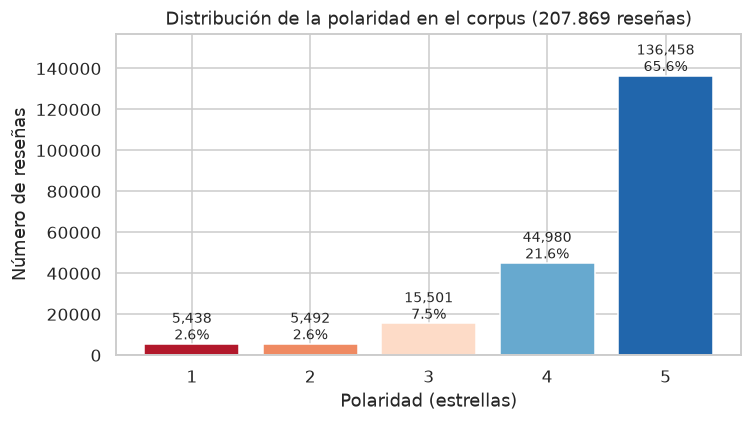

               n      %
Polarity               
1           5438   2.62
2           5492   2.64
3          15501   7.46
4          44980  21.64
5         136458  65.65

Ratio mayoritaria/minoritaria : 25.1 : 1
Polaridad media / mediana     : 4.45 / 5


In [11]:
# =========================================================================
# 3.2 · Distribución de la polaridad
# =========================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
# Paleta fija por estrella, usada en TODO el notebook (rojo = malo, azul = bueno).
PALETA_POL = {1: "#b2182b", 2: "#ef8a62", 3: "#fddbc7", 4: "#67a9cf", 5: "#2166ac"}

conteo = df["Polarity"].value_counts().sort_index()
pct = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(conteo.index, conteo.values, color=[PALETA_POL[i] for i in conteo.index])
for b, n, p in zip(barras, conteo.values, pct):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{n:,}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Polaridad (estrellas)")
ax.set_ylabel("Número de reseñas")
ax.set_title("Distribución de la polaridad en el corpus (207.869 reseñas)")
ax.set_ylim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"n": conteo, "%": pct.round(2)}).to_string())
print(f"\nRatio mayoritaria/minoritaria : {conteo.max() / conteo.min():.1f} : 1")
print(f"Polaridad media / mediana     : {df['Polarity'].mean():.2f} / {df['Polarity'].median():.0f}")

In [12]:
# =========================================================================
# 3.2 · Baseline de clase mayoritaria — de aquí sale la métrica principal
# =========================================================================
from sklearn.metrics import f1_score, accuracy_score

clase_mayoritaria = int(conteo.idxmax())
y_real = df["Polarity"].values
y_pred_may = np.full_like(y_real, clase_mayoritaria)

acc_may = accuracy_score(y_real, y_pred_may)
f1_may = f1_score(y_real, y_pred_may, average="macro", labels=[1, 2, 3, 4, 5], zero_division=0)
f1_por_clase = f1_score(y_real, y_pred_may, average=None, labels=[1, 2, 3, 4, 5], zero_division=0)

print(f"Baseline = predecir SIEMPRE {clase_mayoritaria}★ (sin leer el texto)")
print(f"  accuracy  = {acc_may:.4f}")
print(f"  macro-F1  = {f1_may:.4f}")
print(f"  F1 por clase 1..5 = {[round(v, 3) for v in f1_por_clase]}")

# Línea de referencia para TODAS las tablas de resultados.
BASELINE = {"clase": clase_mayoritaria, "accuracy": float(acc_may), "macro_f1": float(f1_may)}

Baseline = predecir SIEMPRE 5★ (sin leer el texto)
  accuracy  = 0.6565
  macro-F1  = 0.1585
  F1 por clase 1..5 = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.793)]


La siguiente celda traduce ese desbalance en tres cosas concretas: cuánto pesará cada clase
al entrenar, si reformular la tarea ayudaría, y con cuántos ejemplos reales contaremos para
las clases poco frecuentes.

In [13]:
# =========================================================================
# 3.2 (extra) · Qué implica el desbalance para el modelado
# =========================================================================
# a) Pesos de clase para la pérdida (inverso de la frecuencia, normalizado a media 1)
frec = conteo / conteo.sum()
w = (1 / frec) / (1 / frec).sum() * len(conteo)
print("class_weight (1..5):", {e: round(v, 2) for e, v in zip([1, 2, 3, 4, 5], w)})
print(f"  -> un error en 1★ pesará ~{w[1] / w[5]:.0f}x más que uno en 5★\n")

# b) ¿Se escapa del desbalance reformulando la tarea?
c3 = pd.Series(np.select([df["Polarity"] <= 2, df["Polarity"] == 3],
                         ["neg (1-2)", "neu (3)"], "pos (4-5)")).value_counts(normalize=True) * 100
c2 = pd.Series(np.where(df["Polarity"] >= 4, "pos (4-5)", "no-pos (1-3)")).value_counts(normalize=True) * 100
print("Colapsando a 3 clases (%):\n", c3.round(1).to_string())
print("\nColapsando a binario (%):\n", c2.round(1).to_string())

# c) Ejemplos de entrenamiento por clase tras la submuestra estratificada de 40k (split 80%)
proj = (frec * CFG["submuestra"] * 0.8).round().astype(int)
print(f"\nEjemplos de train por clase con submuestra de {CFG['submuestra']:,}:")
print({e: int(v) for e, v in zip([1, 2, 3, 4, 5], proj)})

# d) MAE del baseline mayoritario (para completar su fila en las tablas de resultados)
mae_may = float(np.abs(y_real - clase_mayoritaria).mean())
BASELINE["mae"] = mae_may
print(f"\nMAE del baseline 'siempre 5★': {mae_may:.3f} estrellas")

class_weight (1..5): {1: 2.0, 2: 1.98, 3: 0.7, 4: 0.24, 5: 0.08}
  -> un error en 1★ pesará ~25x más que uno en 5★



Colapsando a 3 clases (%):
 pos (4-5)    87.3
neu (3)       7.5
neg (1-2)     5.3

Colapsando a binario (%):
 pos (4-5)       87.3
no-pos (1-3)    12.7

Ejemplos de train por clase con submuestra de 40,000:
{1: 837, 2: 845, 3: 2386, 4: 6924, 5: 21007}

MAE del baseline 'siempre 5★': 0.549 estrellas


Dos de cada tres reseñas tienen 5 estrellas y solo cinco de cada cien tienen 1 o 2. Este sesgo hacia lo positivo es habitual en sitios de reseñas, así que no es un error a corregir sino una característica del problema.

La consecuencia práctica es que el accuracy (porcentaje de aciertos) deja de servir: un modelo que responda siempre "5 estrellas", sin leer el texto, acierta el 65,7 % de las
veces. Por eso medimos el éxito con el macro-F1, que evalúa la calidad clase por clase y luego promedia; ese mismo modelo perezoso saca un macro-F1 de 0,16, porque falla por
completo en cuatro de las cinco clases. Todo el notebook usa macro-F1 como criterio, y el accuracy solo se muestra al lado de este baseline como referencia.

Para que los modelos no ignoren las clases raras, al entrenar daremos a cada clase un peso inverso a su frecuencia, es decir, un error en una reseña de 1★ pesará unas 25 veces más que uno en
una de 5★.

Aun así el problema no desaparece: agrupando en positivo/neutro/negativo el corpus sigue siendo 87 % positivo, y al reducirlo a 40.000 reseñas para que todo corra en tiempo razonable quedarán apenas ~840 ejemplos de 1★ y ~845 de 2★ para entrenar. Es
suficiente para que el macro-F1 sea informativo, pero poco para conclusiones finas sobre esas dos clases; lo consideraremos en las limitaciones.

### 3.3 Tipo de establecimiento, región y pueblo

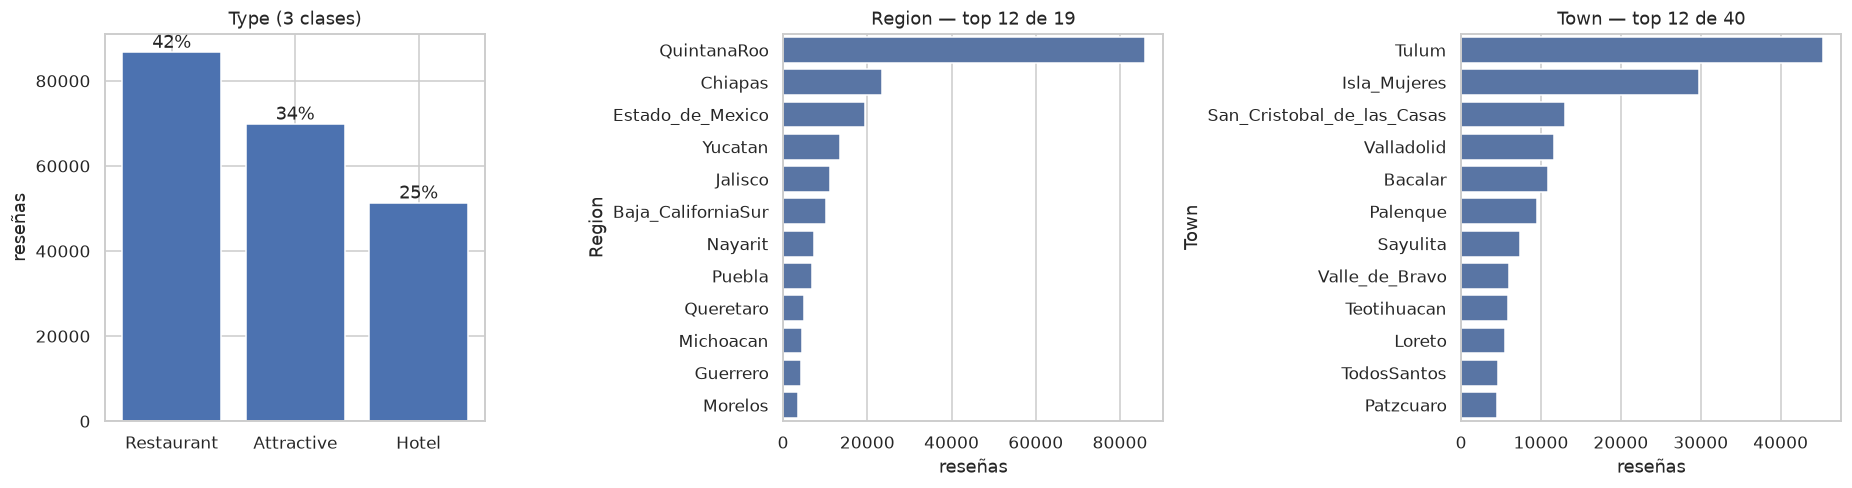

Type (%):
Type
Restaurant    41.7
Attractive    33.6
Hotel         24.7

Concentración geográfica:
  Quintana Roo         : 41.4%
  top 3 regiones       : 62.0%
  Tulum + Isla Mujeres : 36.2%

Regiones completas (n y %):
                        n      %
Region                          
QuintanaRoo         85985  41.36
Chiapas             23427  11.27
Estado_de_Mexico    19437   9.35
Yucatan             13621   6.55
Jalisco             11167   5.37
Baja_CaliforniaSur  10124   4.87
Nayarit              7337   3.53
Puebla               6830   3.29
Queretaro            4879   2.35
Michoacan            4453   2.14
Guerrero             4201   2.02
Morelos              3445   1.66
Veracruz             3335   1.60
San_Luis_Potosi      2217   1.07
Chihuahua            1786   0.86
Coahuila             1741   0.84
Hidalgo              1509   0.73
Oaxaca               1466   0.71
Guanajuato            909   0.44


In [14]:
# =========================================================================
# 3.3 · Tipo de establecimiento, región y pueblo
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

vc_type = df["Type"].value_counts()
axes[0].bar(vc_type.index, vc_type.values, color="#4c72b0")
for i, v in enumerate(vc_type.values):
    axes[0].text(i, v, f"{v / len(df) * 100:.0f}%", ha="center", va="bottom")
axes[0].set_title("Type (3 clases)"); axes[0].set_ylabel("reseñas")

vc_reg = df["Region"].value_counts()
sns.barplot(x=vc_reg.head(12).values, y=vc_reg.head(12).index, ax=axes[1], color="#4c72b0")
axes[1].set_title(f"Region — top 12 de {df['Region'].nunique()}"); axes[1].set_xlabel("reseñas")

vc_town = df["Town"].value_counts()
sns.barplot(x=vc_town.head(12).values, y=vc_town.head(12).index, ax=axes[2], color="#4c72b0")
axes[2].set_title(f"Town — top 12 de {df['Town'].nunique()}"); axes[2].set_xlabel("reseñas")

plt.tight_layout(); plt.show()

print("Type (%):")
print((vc_type / len(df) * 100).round(1).to_string())
print("\nConcentración geográfica:")
print(f"  Quintana Roo         : {vc_reg.iloc[0] / len(df) * 100:.1f}%")
print(f"  top 3 regiones       : {vc_reg.head(3).sum() / len(df) * 100:.1f}%")
print(f"  Tulum + Isla Mujeres : {vc_town.head(2).sum() / len(df) * 100:.1f}%")
print("\nRegiones completas (n y %):")
print(pd.DataFrame({"n": vc_reg, "%": (vc_reg / len(df) * 100).round(2)}).to_string())

El tipo de establecimiento está bastante repartido: 41.7 % restaurantes, 33.6 % atracciones (museos, playas, zonas arqueológicas) y 24.7 % hoteles. Es lo contrario al caso de la polaridad. Por eso, nos puede convenir usar `Type` como tarea de control: si un mismo modelo clasifica bien
el tipo pero mal las estrellas, la dificultad está en la tarea de polaridad, no en el modelo.

La geografía, en cambio, está muy concentrada. Quintana Roo (Cancún, Tulum, Isla Mujeres, Bacalar) reúne el 41 % de las reseñas, las tres regiones más grandes suman el 62 %, y solo
Tulum e Isla Mujeres ya son el 36 %. De las 19 regiones, muchas aportan menos del 1 %.

Aqui hay un riesgo para el modelo, si entrenamos y evaluamos mezclando al azar, el modelo ve durante el entrenamiento reseñas de los mismos hoteles y playas que luego tiene que calificar, y podría aprender a reconocer el destino (nombres propios, topónimos) en lugar del sentimiento.

In [15]:
# (opcional) polaridad media por tipo y por región — anticipo de 3.6
print("Polaridad media por Type:")
print(df.groupby("Type")["Polarity"].mean().round(2).to_string())
print("\nPolaridad media — regiones del held-out del Split B vs. resto:")
ho = ["Chiapas", "Baja_CaliforniaSur", "Queretaro"]
print(f"  held-out : {df[df.Region.isin(ho)]['Polarity'].mean():.2f}")
print(f"  resto    : {df[~df.Region.isin(ho)]['Polarity'].mean():.2f}")

Polaridad media por Type:
Type
Attractive    4.52
Hotel         4.32
Restaurant    4.47

Polaridad media — regiones del held-out del Split B vs. resto:
  held-out : 4.44
  resto    : 4.45


Los hoteles reciben calificaciones algo más bajas que atracciones y restaurantes (4,32
frente a 4,52 y 4,47), aunque la diferencia es pequeña y todas las medias siguen muy altas.
Y las tres regiones que podríamos dejar fuera para una prueba de generalización tienen una
polaridad media (4,44) casi idéntica a la del resto (4,45): esa eventual partición no
arrancaría sesgada por el lado de las etiquetas. Queda como observación.

<!-- LEER: el contraste entre un `Type` balanceado y una polaridad que no lo está, de ahí
     sale la tarea de control de la §13, y la concentración geográfica en Quintana Roo,
     que motiva la partición por región de la §10. -->

### 3.4 Longitud de las reseñas → de dónde sale `MAX_LEN`

Los notebooks guía fijan la longitud de secuencia en 256 o 512 tokens sin justificarlo.
Aquí la derivamos de la distribución real: `MAX_LEN` será el percentil 95 en tokens, y
reportaremos qué fracción de reseñas queda truncada.

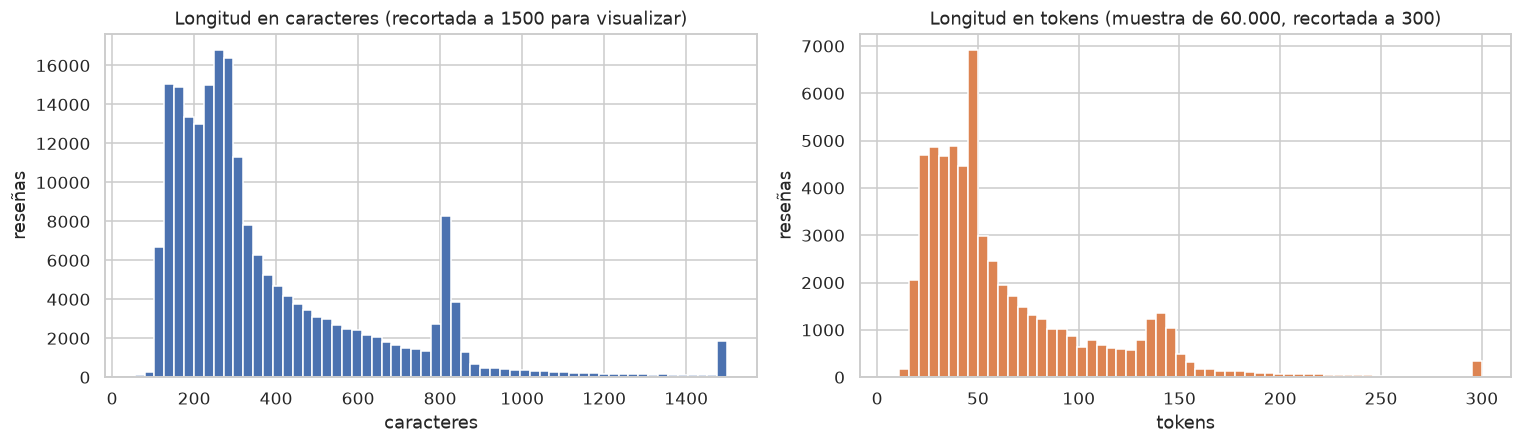

 percentil  caracteres  tokens
        50         284      48
        75         472      81
        90         803     136
        95         839     148
        99        1424     244

Mediana de tokens : 48
MAX_LEN (percentil 95 en tokens, redondeado a decena) = 150
Con ese límite se trunca el 4.4% de las reseñas (solo la cola larga).


In [16]:
# =========================================================================
# 3.4 · Longitud de las reseñas (caracteres y tokens) -> MAX_LEN
# =========================================================================
import re

# Tokenizador de trabajo solo para medir longitudes. El definitivo se fija en 4.1,
# pero usa el mismo criterio: minúsculas, se parte por lo que no sea letra o número,
# se conservan tildes y ñ.
_re_tok = re.compile(r"[^a-záéíóúüñ0-9]+")
def _tok(t):
    return [x for x in _re_tok.sub(" ", t.lower()).split() if x]

df["n_car"] = df["texto"].str.len()

# Contar tokens en las 207k reseñas es lento; usamos una muestra grande y reproducible.
muestra_tok = df["texto"].sample(60000, random_state=SEED).map(lambda t: len(_tok(t)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(df["n_car"].clip(upper=1500), bins=60, color="#4c72b0")
axes[0].set_title("Longitud en caracteres (recortada a 1500 para visualizar)")
axes[0].set_xlabel("caracteres"); axes[0].set_ylabel("reseñas")
axes[1].hist(muestra_tok.clip(upper=300), bins=60, color="#dd8452")
axes[1].set_title("Longitud en tokens (muestra de 60.000, recortada a 300)")
axes[1].set_xlabel("tokens"); axes[1].set_ylabel("reseñas")
plt.tight_layout(); plt.show()

pcts = [50, 75, 90, 95, 99]
tabla_long = pd.DataFrame({
    "percentil": pcts,
    "caracteres": np.percentile(df["n_car"], pcts).round().astype(int),
    "tokens": np.percentile(muestra_tok, pcts).round().astype(int),
})
print(tabla_long.to_string(index=False))

MAX_LEN = int(round(np.percentile(muestra_tok, 95) / 10) * 10)
trunc = (muestra_tok > MAX_LEN).mean()
print(f"\nMediana de tokens : {int(muestra_tok.median())}")
print(f"MAX_LEN (percentil 95 en tokens, redondeado a decena) = {MAX_LEN}")
print(f"Con ese límite se trunca el {trunc * 100:.1f}% de las reseñas (solo la cola larga).")

La mayoría de las reseñas son cortas: la mitad tiene 48 palabras o menos y el 90 % cabe en 136. Pero hay una cola larga que llega a más de 240. Fijamos el límite de longitud (`MAX_LEN`) en 150 palabras, que es el percentil 95: con eso solo se recorta el 4,4 % de las reseñas, y siempre por el final, que suele ser la parte menos informativa.

En los histogramas hay un pico alrededor de las 140 palabras (unos 800 caracteres) que parece un corte fijo del proceso de descarga de las reseñas, no algo propio del lenguaje. El pico del extremo derecho de cada gráfica es solo el efecto de amontonar ahí todo lo que se sale del rango dibujado; los valores reales están en la tabla de percentiles.

<!-- LEER: la asimetría de la distribución y por qué el P95 es el compromiso correcto. -->

### 3.5 Léxico distintivo por polaridad

Las frecuencias crudas están dominadas por palabras funcionales y no distinguen nada. Usamos
**log-odds ratio con prior de Dirichlet**, que mide qué tan sobrerrepresentado está un
término en una clase respecto al resto del corpus y es robusto ante términos poco frecuentes.

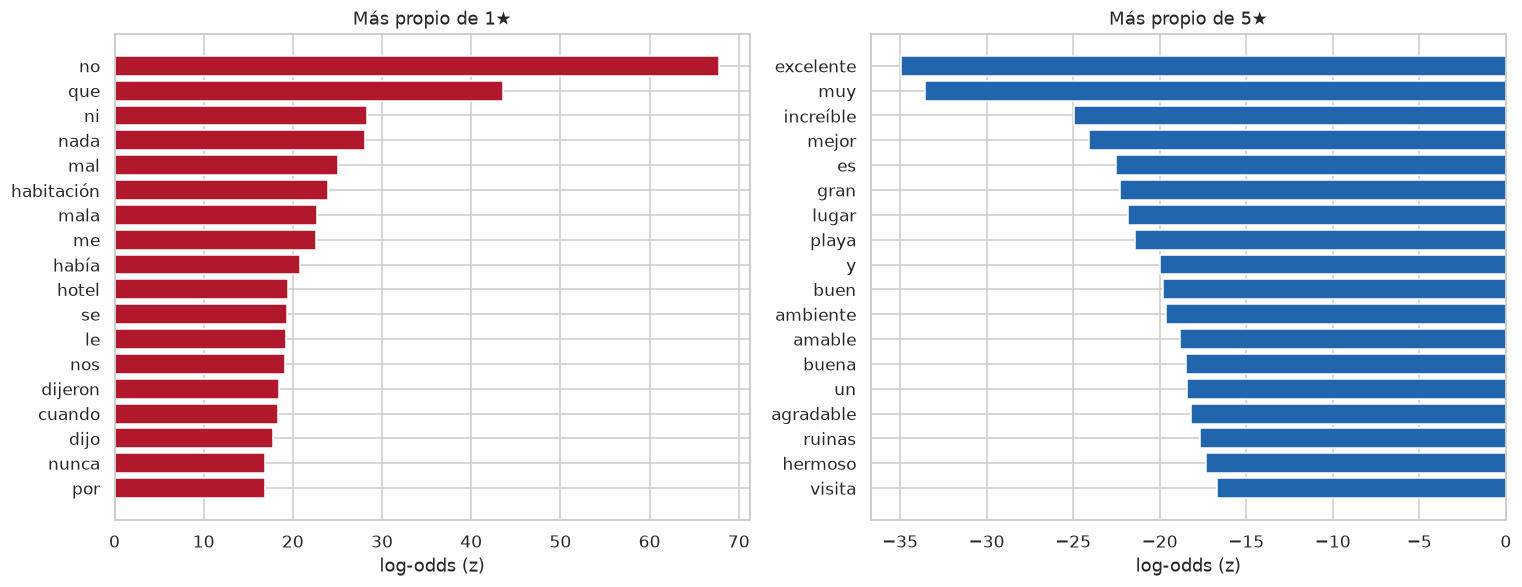

LEXICO[1] (1★): ['no', 'que', 'ni', 'nada', 'mal', 'habitación', 'mala', 'me', 'había', 'hotel', 'se', 'le', 'nos', 'dijeron', 'cuando', 'dijo', 'nunca', 'por']
LEXICO[5] (5★): ['excelente', 'muy', 'increíble', 'mejor', 'es', 'gran', 'lugar', 'playa', 'y', 'buen', 'ambiente', 'amable', 'buena', 'un', 'agradable', 'ruinas', 'hermoso', 'visita']


In [17]:
# =========================================================================
# 3.5 · Léxico distintivo: 1★ frente a 5★ (log-odds con prior de Dirichlet)
# =========================================================================
from collections import Counter

def log_odds(textos_a, textos_b, alpha=0.01, top=18, min_freq=10):
    """z-score de log-odds (Monroe et al. 2008): qué términos distinguen A de B."""
    ca, cb = Counter(), Counter()
    for t in textos_a: ca.update(_tok(t))
    for t in textos_b: cb.update(_tok(t))
    vocab = set(ca) | set(cb)
    na, nb, a0 = sum(ca.values()), sum(cb.values()), alpha * len(vocab)
    z = {}
    for w in vocab:
        if ca[w] + cb[w] < min_freq:
            continue
        la = np.log((ca[w] + alpha) / (na + a0 - ca[w] - alpha))
        lb = np.log((cb[w] + alpha) / (nb + a0 - cb[w] - alpha))
        z[w] = (la - lb) / np.sqrt(1.0 / (ca[w] + alpha) + 1.0 / (cb[w] + alpha))
    ordenado = sorted(z.items(), key=lambda kv: kv[1])
    return ordenado[-top:][::-1], ordenado[:top]   # (más de A, más de B)

txt_1 = df.loc[df["Polarity"] == 1, "texto"]
txt_5 = df.loc[df["Polarity"] == 5, "texto"].sample(len(txt_1) * 2, random_state=SEED)
mas_1, mas_5 = log_odds(txt_1, txt_5)
LEXICO = {1: [w for w, _ in mas_1], 5: [w for w, _ in mas_5]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, datos, titulo, color in [(axes[0], mas_1, "Más propio de 1★", "#b2182b"),
                                 (axes[1], mas_5, "Más propio de 5★", "#2166ac")]:
    palabras, scores = zip(*datos)
    ax.barh(range(len(palabras)), scores, color=color)
    ax.set_yticks(range(len(palabras))); ax.set_yticklabels(palabras); ax.invert_yaxis()
    ax.set_title(titulo); ax.set_xlabel("log-odds (z)")
plt.tight_layout(); plt.show()

print("LEXICO[1] (1★):", LEXICO[1])
print("LEXICO[5] (5★):", LEXICO[5])

En las reseñas de 1★ lo que más pesa es la negación: "no", "ni", "nada", "nunca". Es un hallazgo relevante en cuanto a elegir el modelo, porque un enfoque de bolsa de palabras (que cuenta términos sin mirar el orden) no puede distinguir "no recomiendo" de "recomiendo".
También aparecen mucho "dijeron", "dijo", "nos": en las reseñas malas la gente reconstruye conversaciones con el personal. Y "habitación" y "hotel" se inclinan al lado negativo, lo que encaja con que los hoteles tenían la media de estrellas más baja.

En 5★ dominan los adjetivos de entusiasmo ("excelente", "increíble", "hermoso", "amable", "agradable") mezclados con palabras de lugar ("playa", "ruinas", "lugar", "visita"). Esto
último conviene tenerlo en cuenta: parte de la señal no es sentimiento puro sino relacionado al tema (las atracciones reciben mejores calificaciones que los hoteles), así que un modelo podría acertar en parte fijándose en de qué habla la reseña y no en cómo la valora.

Guardamos ambas listas en `LEXICO` para tenerlas como referencia.

### 3.6 Interacciones

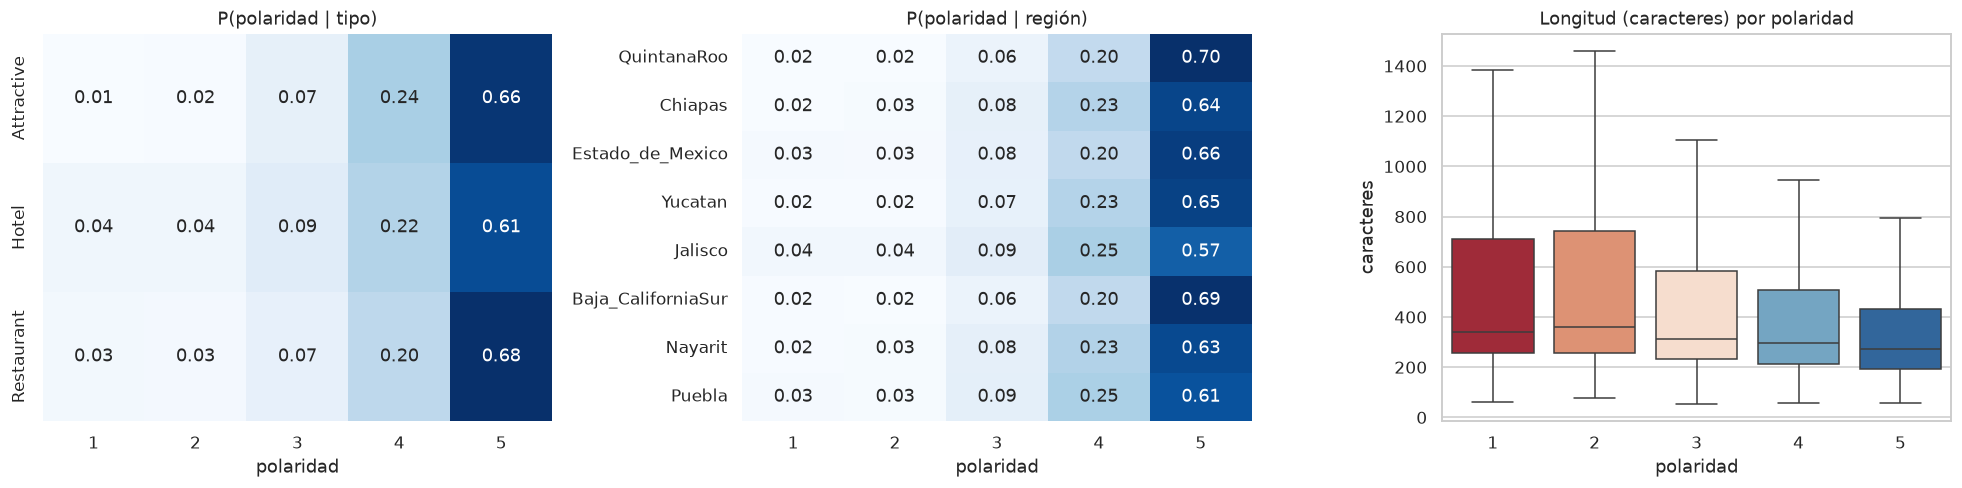

Longitud mediana (caracteres) por polaridad:
Polarity
1    339.0
2    358.0
3    313.0
4    295.0
5    274.0

Polaridad media por región (top 8), de menor a mayor:
Region
Jalisco               4.27
Puebla                4.37
Nayarit               4.42
Estado_de_Mexico      4.43
Chiapas               4.45
Yucatan               4.46
Baja_CaliforniaSur    4.52
QuintanaRoo           4.53


In [18]:
# =========================================================================
# 3.6 · Interacciones: polaridad × tipo, × región, × longitud
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

# 1) P(polaridad | tipo)
ct = pd.crosstab(df["Type"], df["Polarity"], normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("P(polaridad | tipo)"); axes[0].set_xlabel("polaridad"); axes[0].set_ylabel("")

# 2) P(polaridad | región) para las 8 regiones con más reseñas
top8 = df["Region"].value_counts().head(8).index
cr = pd.crosstab(df.loc[df["Region"].isin(top8), "Region"], df["Polarity"], normalize="index")
cr = cr.loc[top8]  # ordenadas por volumen
sns.heatmap(cr, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("P(polaridad | región)"); axes[1].set_xlabel("polaridad"); axes[1].set_ylabel("")

# 3) longitud (caracteres) por polaridad
sns.boxplot(data=df, x="Polarity", y="n_car", hue="Polarity", legend=False,
            palette=PALETA_POL, showfliers=False, ax=axes[2])
axes[2].set_title("Longitud (caracteres) por polaridad")
axes[2].set_xlabel("polaridad"); axes[2].set_ylabel("caracteres")

plt.tight_layout(); plt.show()

print("Longitud mediana (caracteres) por polaridad:")
print(df.groupby("Polarity")["n_car"].median().to_string())
print("\nPolaridad media por región (top 8), de menor a mayor:")
print(df[df["Region"].isin(top8)].groupby("Region")["Polarity"].mean().round(2).sort_values().to_string())

El sesgo positivo es bastante parejo. Por tipo, los hoteles concentran algo más de reseñas negativas (4 % de 1★ y 4 % de 2★, frente al 1–2 % de las atracciones) y algo menos de 5★, aunque la diferencia es moderada.

Por región, la proporción de 5★ va del 57 % (Jalisco) al 70 % (Quintana Roo), y las tres regiones que podríamos apartar para una prueba de generalización (Chiapas, Baja California Sur, Querétaro) caen dentro de ese rango: apartarlas no cambiaría de forma brusca la mezcla de etiquetas.

La longitud sí se relaciona con la polaridad: las reseñas negativas son más largas (mediana de ~340–360 caracteres en 1★ y 2★, frente a ~275 en 5★).
Esto tiene sentido, quien se queja justifica el enojo con detalle, mientras que un "todo excelente" se despacha en una frase.

<!-- LEER: ¿son los hoteles más criticados que las atracciones? ¿escriben más largo quienes
     se quejan? Si la longitud correlaciona con la polaridad, es una señal que el modelo
     puede explotar y que conviene tener presente al interpretar resultados. -->

### 3.7 Cobertura del vocabulario frente a los embeddings preentrenados

El modelo 3 inicializará sus embeddings con vectores de spaCy entrenados sobre español
general. Antes de hacerlo, medimos cuánto de nuestro vocabulario turístico y regional está
efectivamente cubierto.

In [19]:
# =========================================================================
# 3.7 · Cobertura del vocabulario en los vectores de spaCy (es_core_news_lg)
# =========================================================================
import spacy

nlp_vec = spacy.load("es_core_news_lg")
print("Vectores en es_core_news_lg:", nlp_vec.vocab.vectors.shape, "(nº de palabras × dimensiones)")

# Vocabulario del corpus (muestra de 50.000 reseñas para que sea rápido)
cont_vocab = Counter()
for t in df["texto"].sample(50000, random_state=SEED):
    cont_vocab.update(_tok(t))

tipos = list(cont_vocab)
con_vector = [w for w in tipos if nlp_vec.vocab[w].has_vector]
cob_tipos = len(con_vector) / len(tipos)
cob_tokens = sum(cont_vocab[w] for w in con_vector) / sum(cont_vocab.values())

oov = [(w, n) for w, n in cont_vocab.most_common() if not nlp_vec.vocab[w].has_vector][:25]

print(f"\nPalabras distintas en el corpus (muestra): {len(tipos):,}")
print(f"Cobertura por TIPOS  (palabras distintas con vector): {cob_tipos * 100:.1f}%")
print(f"Cobertura por TOKENS (apariciones cubiertas)        : {cob_tokens * 100:.1f}%")
print("\nPalabras frecuentes SIN vector (OOV):")
for w, n in oov:
    print(f"  {w:22s} {n}")

Vectores en es_core_news_lg: (500000, 300) (nº de palabras × dimensiones)



Palabras distintas en el corpus (muestra): 56,301
Cobertura por TIPOS  (palabras distintas con vector): 74.4%
Cobertura por TOKENS (apariciones cubiertas)        : 99.1%

Palabras frecuentes SIN vector (OOV):
  bacalar                953
  sayulita               817
  taxco                  503
  chichen                415
  ajijic                 309
  tlaquepaque            304
  teotihuacan            276
  pátzcuaro              229
  izamal                 216
  patzcuaro              189
  ziggy                  173
  creel                  172
  tequisquiapan          144
  rolandi                143
  tepoztlán              121
  nautibeach             113
  mazunte                109
  tepozteco              105
  covid                  103
  teotihuacán            102
  malinalco              98
  qubano                 98
  atlixco                97
  mayan                  95
  xilitla                89


Casi todas las palabras que aparecen en las reseñas (99,1 % de las apariciones) tienen vector preentrenado. La cobertura baja al 74 % si contamos palabras distintas, pero lo que
falta son casi en su totalidad nombres propios: destinos (Bacalar, Sayulita, Taxco, Chichén,
Teotihuacán) y nombres de hoteles y restaurantes (Ziggy, Rolandi, Nautibeach). Vocabulario
de sentimiento sin cubrir prácticamente no hay.

Esto tiene dos lecturas. Partir de vectores preentrenados es una buena apuesta, porque el modelo no tiene que aprender desde cero qué significan "excelente" o "pésimo". Y como los nombres de lugar no tienen vector, un modelo que los use tal cual no puede apoyarse en el destino para adivinar la nota; en cambio, si dejamos que ajuste los vectores durante el entrenamiento, podría construir representaciones para esos nombres y usarlas como atajo.

Por eso conviene probar las dos variantes, vectores congelados y vectores ajustados, y comparar.
También se nota algo de ruido ortográfico: "pátzcuaro" y "patzcuaro", "teotihuacán" y "teotihuacan", cuentan como palabras distintas por la tilde.

In [20]:
# =========================================================================
# 3.7b · Tres cifras para cerrar el diagnóstico
# =========================================================================
# (1) ¿Por qué un vocabulario de 30.000? Cobertura de apariciones según el corte.
cont_full = Counter()
for t in df["texto"].sample(80000, random_state=SEED):
    cont_full.update(_tok(t))
total = sum(cont_full.values())
print("Cobertura de apariciones según el tamaño de vocabulario:")
for k in (10000, 20000, 30000, 50000):
    cub = sum(n for _, n in cont_full.most_common(k))
    print(f"  vocab {k:>6,} -> {cub / total * 100:.2f}%")
print(f"  (palabras distintas en la muestra: {len(cont_full):,})")

# (2) Ruido de etiqueta: texto que contradice las estrellas.
neg_fuerte = {"pésimo", "pesimo", "horrible", "terrible", "asqueroso", "sucio", "estafa",
              "engaño", "robo", "nunca", "jamás", "malísimo", "peor"}
pos_fuerte = {"excelente", "maravilloso", "hermoso", "increíble", "perfecto", "espectacular",
              "encantó", "encanto", "recomiendo"}
def contiene(texto, palabras):
    return len(set(_tok(texto)) & palabras) > 0

r5 = df.loc[df["Polarity"] == 5, "texto"].map(lambda t: contiene(t, neg_fuerte)).mean()
r1 = df.loc[df["Polarity"] == 1, "texto"].map(lambda t: contiene(t, pos_fuerte)).mean()
print(f"\nReseñas de 5★ con vocabulario muy negativo en el texto: {r5 * 100:.1f}%")
print(f"Reseñas de 1★ con vocabulario muy positivo en el texto: {r1 * 100:.1f}%")

# (3) Densidad de negación por polaridad (negaciones por cada 100 palabras).
neg_tok = {"no", "ni", "nada", "nunca", "tampoco", "jamás", "sin"}
def dens_neg(texto):
    toks = _tok(texto)
    return sum(w in neg_tok for w in toks) / max(len(toks), 1) * 100
print("\nNegaciones por cada 100 palabras, según la polaridad:")
for p in (1, 2, 3, 4, 5):
    s = df.loc[df["Polarity"] == p, "texto"].sample(
        min(5000, int((df["Polarity"] == p).sum())), random_state=SEED)
    print(f"  {p}★: {s.map(dens_neg).mean():.2f}")

Cobertura de apariciones según el tamaño de vocabulario:
  vocab 10,000 -> 96.73%
  vocab 20,000 -> 98.47%


  vocab 30,000 -> 99.08%
  vocab 50,000 -> 99.59%
  (palabras distintas en la muestra: 71,266)



Reseñas de 5★ con vocabulario muy negativo en el texto: 3.3%
Reseñas de 1★ con vocabulario muy positivo en el texto: 15.3%

Negaciones por cada 100 palabras, según la polaridad:


  1★: 3.75


  2★: 3.47


  3★: 2.72
  4★: 1.39


  5★: 1.11


### 3.8 Síntesis: del hallazgo a la decisión

<!-- REDACTAR - la celda más importante del EDA. Una lista numerada, cada línea con la
     forma «hallazgo → decisión → dónde se aplica»:

     1. Desbalance 65/22/7/3/3  →  macro-F1 como métrica principal  →  §4, todas las tablas
     2. Distribución de longitudes  →  MAX_LEN = P95  →  §4
     3. Concentración en Quintana Roo  →  partición geográfica  →  §10
     4. Objetivo ordinal  →  MAE y QWK + formulaciones ordinales  →  §9
     5. Cobertura de embeddings  →  expectativa sobre el modelo 3  →  §7
     6. `Type` balanceado  →  tarea de control  →  §13
-->

| Hallazgo del EDA | Decisión que induce |
|---|---|
| El corpus trae mojibake y colas "...Más" de TripAdvisor, pero cero reseñas vacías y solo 182 duplicados exactos. | Se corrige el texto (`ftfy` + recorte) y se eliminan los duplicados; nada más. Corpus de trabajo: 207.869 reseñas. |
| El 66 % de las reseñas son 5★; predecir siempre "5" da 65,7 % de accuracy pero 0,16 de macro-F1. | La métrica principal es **macro-F1**. El accuracy solo se reporta junto a este baseline. |
| Las clases 1★ y 2★ juntas son el 5 %; tras reducir a 40.000 reseñas quedan ~840 ejemplos de cada una. | Se pondera cada clase por el inverso de su frecuencia al entrenar, y se asume desde ya que las métricas de 1★ y 2★ serán ruidosas (limitación). |
| Longitudes muy asimétricas: mediana 48 palabras, percentil 95 = 148. | **`MAX_LEN` = 150 palabras** (percentil 95); trunca solo el 4 % de las reseñas. |
| En 1★ domina la negación: 3,75 por cada 100 palabras, frente a 1,11 en 5★. | Una bolsa de palabras no distingue "no recomiendo" de "recomiendo": se justifica probar modelos que miran el orden (LSTM) y en ambos sentidos (bidireccional). |
| El 99 % de las apariciones tiene vector preentrenado; lo que falta son nombres de destinos y de hoteles. | Se inicializan los embeddings con los de spaCy y se prueban **congelados y ajustados**, porque ajustar podría reintroducir el destino como atajo. |
| Quintana Roo es el 41 % del corpus; con partición aleatoria el modelo ve en entrenamiento los mismos destinos que evalúa. | Se prueba además una **partición geográfica** (Chiapas, Baja California Sur y Querétaro fuera del entrenamiento) para medir generalización a destinos nuevos. |
| La escala 1–5 está ordenada: confundir 4★ con 5★ no equivale a confundir 1★ con 5★. | Además de macro-F1 se reportan **MAE y QWK**, y se prueba una formulación de regresión con umbrales. |
| `Type` está equilibrado (42/34/25) y no es ordinal. | Sirve de **tarea de control**: la misma arquitectura sobre `Type` dirá si un macro-F1 flojo en polaridad es culpa de la tarea o del modelo. |
| El 15 % de las reseñas de 1★ usan vocabulario muy positivo (y el 3 % de las de 5★, muy negativo). | Hay ruido de etiqueta y reseñas mixtas; ponen un techo al rendimiento y se analizan en la sección de errores. |

---

> ### Del EDA a esta entrega
>
> La tabla anterior (§3.8) mapea cada hallazgo a las secciones del Miniproyecto 1. Esta lo
> retraduce a las decisiones de este notebook, sin tocar el EDA original.

| Hallazgo del EDA | Qué decide en esta entrega | Dónde |
|---|---|---|
| 66 % de las reseñas son 5★; predecir siempre «5» da 65,7 % de accuracy y 0,16 de macro-F1 | **macro-F1** sigue siendo la métrica principal. El notebook guía de la Sesión 2 reporta solo accuracy; sobre este corpus esa métrica no distinguiría un Transformer entrenado de uno que no aprendió nada | §4.5 |
| Clases 1★ y 2★ con ~840 ejemplos cada una tras submuestrear | Pérdida ponderada por el inverso de la frecuencia; se asume que sus métricas serán ruidosas | §5, §6 |
| Longitudes muy asimétricas: mediana 48 palabras, P95 = 148 | `MAX_LEN` = **P95 recalculado sobre tokens BPE**, no heredado. En la atención el costo crece con el **cuadrado** de la longitud: el guía fija 2.048 y lo llama «una decisión ingenua» | §4.2, §11 |
| 26 % de las palabras distintas sin vector, pero solo 1,5 % de las *apariciones* en test (medido en el propio Miniproyecto 1) | El vocabulario por palabras de MP1 **se hereda tal cual** (D-214): el costo real de no usar subword es marginal. BPE se mide aparte, como variante, en §8/§9 (D-216) | §4, §8 |
| En 1★ domina la negación: 3,75 por cada 100 palabras frente a 1,11 en 5★ | Es la hipótesis **H1** de la portada y la razón de ser de la comparación con el MLP. Se contrasta en la tabla de §7, en el control sin posicional de §8 y en los pesos de atención de §14 | §7, §8, §14 |
| La escala 1–5 es ordinal | Se reportan **MAE y QWK** junto a macro-F1, como en la entrega anterior, para que la comparación entre proyectos sea directa | §4.5, §13 |
| `Type` está equilibrado (42/34/25) y no es ordinal | Se recupera como **tarea de control**: la misma arquitectura, sin cambiar una línea, dirá si un macro-F1 flojo en polaridad es culpa de la tarea o del modelo | §12 |
| 15 % de las reseñas de 1★ usan vocabulario muy positivo | Ruido de etiqueta: pone un techo al rendimiento alcanzable y se analiza en la sección de errores | §16 |
| El corpus es de dominio, coloquial y con faltas de ortografía | Material para la **demo**: escribir una reseña propia y ver qué predice el modelo y dónde mira | §15 |

---

## 4. Preprocesamiento y protocolo experimental

Todo lo que sigue está al servicio de una sola exigencia: que las comparaciones de las
Secciones 7, 9, 12 y 13 signifiquen algo. Eso obliga a fijar de antemano, y una sola vez, el
tokenizador, la longitud de secuencia, la submuestra, la partición y las métricas.

Se hereda **tal cual** del Miniproyecto 1 (D-214): mismo tokenizador por palabras, mismo
vocabulario de 30.000 tokens, misma submuestra estratificada de 40.000 reseñas, mismo
Split A, mismo `MAX_LEN = 150`, misma función `evaluar(...)`. No es pereza — es la decisión
que hace posible la Sección 13: si el vocabulario cambiara, una diferencia de macro-F1 contra
los modelos de esa entrega podría deberse a la tokenización, a la arquitectura, o a una
mezcla de las dos, sin forma de separarlas.

Lo único genuinamente nuevo de esta sección es el `Dataset` de PyTorch (§4.4): en el
Miniproyecto 1 devuelve `(ids, longitudes, y)` para alimentar `pack_padded_sequence`; aquí
además construye la **máscara de atención** que el Transformer necesita.

Y una advertencia que se cumple, no se promete: el vocabulario por palabras puede convenirle
menos al Transformer que uno subword. Por eso el Transformer de la Sección 6 se entrena
también con BPE, como variante medida en la Sección 8 (D-216) — la tabla de la Sección 13
usa el vocabulario compartido con MP1 y se lee junto a esa variante, no en su lugar.

### 4.1 Tokenizador y vocabulario — heredados del Miniproyecto 1

Tokenizador por palabras: minúsculas, se separa por todo lo que no sea letra o número, se
conservan tildes y ñ. El vocabulario se construye por **frecuencia** (`most_common`), no por
orden de aparición — la corrección que MP1 ya documentó (MP1 §D-002.1) frente al notebook
guía de su propia sesión.

El EDA §3.7 midió que el 26 % de las palabras *distintas* del corpus no tiene vector
preentrenado. Pero la cifra que importa para un vocabulario cerrado es otra: el propio
Miniproyecto 1 verificó que ese vocabulario de 30.000 palabras deja fuera solo el **1,5 % de
las apariciones** en test (D-214). El costo real de no usar subword aquí es marginal, no el
problema que parecía a primera vista.

In [ ]:
# =========================================================================
# 4.1 · Tokenizador y vocabulario — heredados del Miniproyecto 1 (D-214)
# =========================================================================
_RE_TOKEN = re.compile(r"[^a-záéíóúüñ0-9]+")

def tokenizar(texto: str):
    """Minúsculas; se parte por todo lo que no sea letra o número; se conservan
    tildes y ñ. Mismo criterio que el Miniproyecto 1 y que el EDA de la §3."""
    return [t for t in _RE_TOKEN.sub(" ", texto.lower()).split() if t]

PAD, UNK = 0, 1

def construir_vocab(textos, max_vocab):
    """Vocabulario por FRECUENCIA (most_common), con [PAD]=0 y [UNK]=1 reservados."""
    cont = Counter()
    for t in textos:
        cont.update(tokenizar(t))
    vocab = {"[PAD]": PAD, "[UNK]": UNK}
    for palabra, _ in cont.most_common(max_vocab - 2):
        vocab[palabra] = len(vocab)
    return vocab

def codificar(texto, vocab, max_len=None):
    max_len = max_len or MAX_LEN
    ids = [vocab.get(t, UNK) for t in tokenizar(texto)[:max_len]]
    n_real = max(len(ids), 1)
    ids += [PAD] * (max_len - len(ids))
    return ids, n_real

ej = df["texto"].iloc[0]
print("Reseña :", ej[:150], "...")
print("Tokens :", tokenizar(ej)[:25], "...")


In [ ]:
# --- Demostración ida y vuelta, con un vocabulario provisional (el definitivo
#     sale en §4.3, solo del texto de entrenamiento de Split A) ---
_vocab_demo = construir_vocab(df["texto"].sample(20000, random_state=SEED), CFG["max_vocab"])
_id2tok_demo = {i: t for t, i in _vocab_demo.items()}

frase = "El hotel estaba sucio y el sargazo cubría toda la playa. No volvería."
ids, n = codificar(frase, _vocab_demo, max_len=20)
print("Texto        :", frase)
print("Tokens       :", tokenizar(frase))
print("IDs          :", ids)
print("Reconstruido :", [_id2tok_demo[i] for i in ids])
print(f"\n{n} tokens reales; los otros {20 - n} son [PAD] (relleno para que todas las")
print("secuencias tengan el mismo largo y se puedan procesar por lotes).")
del _vocab_demo, _id2tok_demo


### 4.2 Submuestra — idéntica al Miniproyecto 1

Estratificada por `Polarity`, 40.000 reseñas, `SEED = 42`. Se preservan las proporciones del
corpus completo en vez de balancear por submuestreo: el desbalance es una propiedad del
dominio que el trabajo estudia, no un artefacto a eliminar (MP1 §D-004).

In [ ]:
# =========================================================================
# 4.2 · Submuestra estratificada (40k, SEED=42) — heredada del Miniproyecto 1
# =========================================================================
from sklearn.model_selection import train_test_split

N_SUB = min(CFG["submuestra"], len(df))
sub, _ = train_test_split(df, train_size=N_SUB, random_state=SEED, stratify=df["Polarity"])
sub = sub.reset_index(drop=True)

comp = pd.DataFrame({
    "corpus (%)":     (df["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2),
    "submuestra (%)": (sub["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2),
    "n en submuestra": sub["Polarity"].value_counts().sort_index(),
})
print(f"Submuestra: {len(sub):,} reseñas (de {len(df):,}), estratificada por polaridad.")
print(comp.to_string())


### 4.3 Split A y vocabulario definitivo

80/10/10 estratificado por `Polarity`, `SEED = 42`. El vocabulario definitivo se construye
**solo con el texto de entrenamiento** de este split — nunca con validación ni test, para no
filtrar información. Se verifica la tasa de `[UNK]` y de truncamiento sobre el test; deben
acercarse a las del Miniproyecto 1 (D-207).

In [ ]:
# =========================================================================
# 4.3 · Split A — aleatorio estratificado 80/10/10 (heredado del Miniproyecto 1)
# =========================================================================
idx = np.arange(len(sub))
y = sub["Polarity"].values

idx_tr, idx_tmp = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=y)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED, stratify=y[idx_tmp])
SPLIT_A = {"train": idx_tr, "val": idx_va, "test": idx_te}

print("Split A:")
for k, v in SPLIT_A.items():
    d = (pd.Series(y[v]).value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"  {k:5s}: {len(v):>6,} reseñas  |  % por estrella: {d.tolist()}")

# Vocabulario definitivo: SOLO con el texto de entrenamiento de Split A (sin fuga)
vocab = construir_vocab(sub.iloc[SPLIT_A["train"]]["texto"], CFG["max_vocab"])
id2tok = {i: t for t, i in vocab.items()}
print(f"\nVocabulario definitivo: {len(vocab):,} tokens")

unk = tot = trunc = 0
for t in sub.iloc[SPLIT_A["test"]]["texto"]:
    toks = tokenizar(t)
    tot += len(toks); unk += sum(w not in vocab for w in toks); trunc += len(toks) > MAX_LEN
print(f"En test -> tokens fuera del vocabulario: {unk / tot * 100:.1f}%  |  "
      f"reseñas truncadas por MAX_LEN: {trunc / len(SPLIT_A['test']) * 100:.1f}%")


### 4.4 `Dataset` y `DataLoader` — con máscara de atención

Aquí está el único cambio real frente al Miniproyecto 1. Su `Dataset` devuelve
`(ids, longitudes, y)`: la LSTM usa las longitudes con `pack_padded_sequence` para no leer
padding. El Transformer no tiene una noción de "hasta dónde llegar" — necesita una **máscara
booleana** explícita, del mismo largo que la secuencia, para que la atención (§6.2) y el
pooling (§6.4) ignoren el relleno. Se deriva de las mismas longitudes, así que no hay
información nueva: solo una forma distinta de expresarla.

In [ ]:
# =========================================================================
# 4.4 · Dataset y DataLoaders — con máscara de atención (lo único nuevo de §4)
# =========================================================================
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

def codificar_todo(textos, vocab, max_len=None):
    max_len = max_len or MAX_LEN
    X = np.zeros((len(textos), max_len), dtype=np.int64)
    L = np.zeros(len(textos), dtype=np.int64)
    for i, t in enumerate(textos):
        ids = [vocab.get(w, UNK) for w in tokenizar(t)[:max_len]]
        L[i] = max(len(ids), 1)
        X[i, :len(ids)] = ids
    return torch.from_numpy(X), torch.from_numpy(L)

XIDS, XLEN = codificar_todo(sub["texto"].values, vocab)
# Máscara booleana derivada de las longitudes: 1.0 = token real, 0.0 = padding.
XMASK = (torch.arange(MAX_LEN).unsqueeze(0) < XLEN.unsqueeze(1)).float()
print("Tensores del corpus:", tuple(XIDS.shape), "| máscara:", tuple(XMASK.shape))

POL2IDX = {p: p - 1 for p in ESTRELLAS}
IDX2POL = {i: p for p, i in POL2IDX.items()}
y_idx = sub["Polarity"].map(POL2IDX).values.astype(np.int64)

class ResenasDS(Dataset):
    """Devuelve (ids, máscara, y). Sustituye a las `longitudes` del Miniproyecto 1
    por la máscara booleana que la atención (y su pooling) necesitan."""
    def __init__(self, indices, etiquetas):
        self.ids = XIDS[indices]
        self.mask = XMASK[indices]
        self.y = torch.tensor(np.asarray(etiquetas)[indices], dtype=torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):  return self.ids[i], self.mask[i], self.y[i]

def hacer_loaders(split, etiquetas, batch=None):
    b = batch or CFG["batch"]
    mk = lambda parte: DataLoader(ResenasDS(split[parte], etiquetas),
                                  batch_size=b, shuffle=(parte == "train"), generator=G)
    return mk("train"), mk("val"), mk("test")

def pesos_de_clase(indices, n_clases=5):
    c = np.bincount(y_idx[indices], minlength=n_clases).astype(float)
    w = c.sum() / (n_clases * np.maximum(c, 1))
    return torch.tensor(w, dtype=torch.float32, device=DISPOSITIVO)

print("ResenasDS, hacer_loaders(), pesos_de_clase() listos (con máscara de atención).")


### 4.5 Métricas y baselines

Las mismas seis métricas del Miniproyecto 1, calculadas por la misma función para todos los
modelos sin excepción: **macro-F1** (principal), accuracy (solo junto al baseline
mayoritario), **MAE** y **QWK** (la escala es ordinal), F1 por clase (diagnóstico) y tiempo
de entrenamiento (costo). Se añade una columna de **entorno de medición** (D-209): esta
corrida es local con GPU RTX 4060, distinta de la RTX 3050 Laptop del Miniproyecto 1.

**Verificación bloqueante (D-207):** los baselines deben reproducir los del Miniproyecto 1
(accuracy 0.6565, macro-F1 0.1585). Si no lo hacen, la submuestra o el split no son los
mismos, y la Sección 13 queda invalidada hasta corregirlo.

In [ ]:
# =========================================================================
# 4.5 · Función de evaluación única + baselines — heredadas del Miniproyecto 1
# =========================================================================
from sklearn.metrics import (f1_score, accuracy_score, mean_absolute_error,
                             cohen_kappa_score, confusion_matrix, classification_report)

ESTRELLAS = [1, 2, 3, 4, 5]
ENTORNO = "Local · RTX 4060"   # D-209: se declara junto a cada resultado
RESULTADOS = []   # una fila por modelo
PREDS = {}        # nombre -> (y_true, y_pred) en el test de Split A

def evaluar(y_true, y_pred, nombre, registrar=True, n_params=None, segundos=None,
            entorno=None):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    f1c = f1_score(y_true, y_pred, average=None, labels=ESTRELLAS, zero_division=0)
    fila = {
        "modelo":   nombre,
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=ESTRELLAS, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "mae":      mean_absolute_error(y_true, y_pred),
        "qwk":      cohen_kappa_score(y_true, y_pred, weights="quadratic", labels=ESTRELLAS),
        **{f"f1_{e}": v for e, v in zip(ESTRELLAS, f1c)},
        "n_params": n_params, "segundos": segundos, "entorno": entorno or ENTORNO,
    }
    if registrar:
        RESULTADOS.append(fila)
    print(f"{nombre:38s} | macro-F1 {fila['macro_f1']:.4f} | acc {fila['accuracy']:.4f} "
          f"| MAE {fila['mae']:.3f} | QWK {fila['qwk']:.4f}")
    return fila

y_tr_A = sub.iloc[SPLIT_A["train"]]["Polarity"].values
y_te_A = sub.iloc[SPLIT_A["test"]]["Polarity"].values

# 1) Clase mayoritaria
clase = int(pd.Series(y_tr_A).value_counts().idxmax())
evaluar(y_te_A, np.full_like(y_te_A, clase), f"Baseline · siempre {clase}★")

# 2) Azar estratificado
fijar_semilla()
p = pd.Series(y_tr_A).value_counts(normalize=True).sort_index()
y_azar = np.random.choice(p.index.values, size=len(y_te_A), p=p.values)
evaluar(y_te_A, y_azar, "Baseline · azar estratificado")

print("\nVerificación contra el Miniproyecto 1 (accuracy 0.6565, macro-F1 0.1585):")
display(pd.DataFrame(RESULTADOS)[["modelo", "macro_f1", "accuracy", "mae", "qwk"]].round(4))


---

## 5. Modelo A — MLP simple

La rúbrica pide comparar el Transformer «frente a un modelo más simple de tipo MLP». Un MLP
sobre embeddings promediados es **invariante al orden**: para él, «no está mal» y «está mal,
no» producen la misma representación. Como el EDA §3.5 mostró que la negación es el rasgo que
más distingue a las reseñas de 1★, este modelo mide directamente cuánto de la tarea se
resuelve ignorando por completo la sintaxis.

**Por qué embeddings promediados y no TF-IDF (D-215).** El MLP comparte con el Transformer
el mismo vocabulario, el mismo tokenizador, la misma tabla de embeddings inicial, la misma
máscara, la misma partición, la misma ponderación de clases, el mismo optimizador y el mismo
bucle de entrenamiento. La **única** diferencia estructural es que el Transformer inserta
bloques de atención entre los embeddings y el *pooling*, y el MLP no. Con TF-IDF esa promesa
no se sostendría: cambiaría la representación de entrada además de la arquitectura, y una
diferencia de macro-F1 dejaría de ser atribuible con claridad a la atención.

In [ ]:
# =========================================================================
# 5 · Infraestructura de entrenamiento — compartida por el MLP y el Transformer
# =========================================================================
@torch.no_grad()
def predecir(modelo, loader, devolver_pesos=False):
    modelo.eval()
    reales, preds, pesos = [], [], []
    for ids, mask, yb in loader:
        ids, mask = ids.to(DISPOSITIVO), mask.to(DISPOSITIVO)
        out = modelo(ids, mask)
        if isinstance(out, tuple):
            out, w = out
            if devolver_pesos: pesos.append(w.cpu())
        preds.append(out.argmax(1).cpu().numpy())
        reales.append(yb.numpy().astype(int))
    yt = np.array([IDX2POL[int(i)] for i in np.concatenate(reales)])
    yp = np.array([IDX2POL[int(i)] for i in np.concatenate(preds)])
    return (yt, yp, torch.cat(pesos)) if devolver_pesos else (yt, yp)

def _lr_warmup(paso, pasos_totales, pasos_warmup, lr_base):
    """Calienta linealmente hasta `lr_base` y luego decae linealmente a 0 (paper §5.3).
    Con Post-LN (§6.3) el warmup no es cosmético: sin él, Post-LN entrena inestable
    o no converge en absoluto (Xiong et al., 2020) — D-204."""
    if paso < pasos_warmup:
        return lr_base * (paso + 1) / max(pasos_warmup, 1)
    progreso = (paso - pasos_warmup) / max(pasos_totales - pasos_warmup, 1)
    return lr_base * max(0.0, 1 - progreso)

def entrenar(modelo, dl_tr, dl_va, *, epocas=None, lr=None, pesos=None,
             warmup_frac=None, label_smoothing=None, nombre="modelo"):
    """Bucle compartido por el MLP (§5) y el Transformer (§6): AdamW + warmup lineal
    + label smoothing (D-211), con early stopping por macro-F1 de VALIDACIÓN — no por
    pérdida de entrenamiento, que es la señal que el notebook guía usa y que no puede
    detectar sobreajuste (D-204)."""
    modelo = modelo.to(DISPOSITIVO)
    epocas = epocas or CFG["epocas"]; lr = lr or CFG["lr"]
    warmup_frac = CFG["warmup_frac"] if warmup_frac is None else warmup_frac
    label_smoothing = CFG["label_smoothing"] if label_smoothing is None else label_smoothing

    opt = torch.optim.AdamW(modelo.parameters(), lr=lr, weight_decay=1e-4)
    crit = nn.CrossEntropyLoss(weight=pesos, label_smoothing=label_smoothing)

    pasos_totales = max(1, epocas * len(dl_tr))
    pasos_warmup = max(1, int(pasos_totales * warmup_frac))
    paso = 0

    mejor, mejor_estado, sin_mejora, hist = -1.0, None, 0, []
    t0 = time.time()
    for ep in range(1, epocas + 1):
        modelo.train(); suma = 0.0
        for ids, mask, yb in dl_tr:
            ids, mask, yb = ids.to(DISPOSITIVO), mask.to(DISPOSITIVO), yb.to(DISPOSITIVO)
            for g in opt.param_groups:
                g["lr"] = _lr_warmup(paso, pasos_totales, pasos_warmup, lr)
            opt.zero_grad()
            out = modelo(ids, mask)
            if isinstance(out, tuple): out = out[0]
            loss = crit(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 5.0)
            opt.step(); paso += 1
            suma += loss.item() * len(yb)
        yt, yp = predecir(modelo, dl_va)
        vf1 = f1_score(yt, yp, average="macro", labels=ESTRELLAS, zero_division=0)
        vmae = mean_absolute_error(yt, yp)
        hist.append({"epoca": ep, "loss": suma / len(dl_tr.dataset), "val_f1": vf1,
                     "val_mae": vmae, "lr": opt.param_groups[0]["lr"]})
        marca = ""
        if vf1 > mejor:
            mejor, sin_mejora = vf1, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
            marca = " *"
        else:
            sin_mejora += 1
        print(f"  época {ep:2d} | loss {hist[-1]['loss']:.4f} | val macro-F1 {vf1:.4f} "
              f"| val MAE {vmae:.3f} | lr {hist[-1]['lr']:.2e}{marca}")
        if sin_mejora >= CFG["paciencia"]:
            print(f"  parada temprana (sin mejora en {CFG['paciencia']} épocas)"); break
    modelo.load_state_dict(mejor_estado)
    n_par = sum(p.numel() for p in modelo.parameters())
    return modelo, hist, time.time() - t0, n_par

print("predecir() y entrenar() listos (compartidos por §5 y §6).")


In [ ]:
# =========================================================================
# 5 · Modelo A — MLP sobre embeddings promediados (enmascarados) — D-215
# =========================================================================
class ClasificadorMLP(nn.Module):
    """Embedding entrenable -> promedio ENMASCARADO -> MLP. Comparte vocabulario,
    tokenizador, MAX_LEN, máscara, partición y bucle de entrenamiento con el
    Transformer (§6): la única diferencia estructural es que aquí no hay bloques
    de atención entre el embedding y el pooling."""
    def __init__(self, tam_vocab, n_clases=5, emb_dim=None, hidden=None):
        super().__init__()
        emb_dim = emb_dim or CFG["emb_dim"]
        hidden = hidden or CFG["hidden"]
        self.embedding = nn.Embedding(tam_vocab, emb_dim, padding_idx=PAD)
        self.dropout = nn.Dropout(CFG["dropout"])
        self.clasificador = nn.Sequential(
            nn.Linear(emb_dim, hidden), nn.ReLU(), nn.Dropout(CFG["dropout"]),
            nn.Linear(hidden, n_clases),
        )

    def forward(self, ids, mask):
        emb = self.embedding(ids)                             # (batch, seq, emb)
        m = mask.unsqueeze(-1)                                 # (batch, seq, 1)
        rep = (emb * m).sum(dim=1) / m.sum(dim=1).clamp(min=1)  # promedio SOLO de tokens reales
        return self.clasificador(self.dropout(rep))

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
pesos_mlp = pesos_de_clase(SPLIT_A["train"])

mlp = ClasificadorMLP(len(vocab))
mlp, hist_mlp, seg_mlp, par_mlp = entrenar(mlp, dl_tr, dl_va, pesos=pesos_mlp, nombre="MLP")

yt_mlp, yp_mlp = predecir(mlp, dl_te)
evaluar(yt_mlp, yp_mlp, "A · MLP (embeddings promediados)", n_params=par_mlp, segundos=seg_mlp)
PREDS["A · MLP (embeddings promediados)"] = (yt_mlp, yp_mlp)


<!-- LEER: macro-F1, MAE, QWK del MLP frente a los baselines. ¿Qué clases abandona
     primero? Se retoma en §7 frente al Transformer. -->

---

## 6. Modelo B — El Transformer, pieza por pieza

Implementamos el codificador del paper original sin recurrir a `nn.MultiheadAttention` ni a
`nn.TransformerEncoderLayer`. Cada subsección construye una pieza, la prueba sobre un tensor
de juguete y explica qué papel cumple; al final se ensamblan y se entrena **con el mismo
vocabulario por palabras del MLP y de MP1** (D-214, D-216) — la variante con BPE se mide por
separado en la Sección 8.

Seguimos la estructura del notebook de la Sesión 2, corrigiendo tres desviaciones respecto
del paper que allí quedaron (D-202):

| Pieza | Notebook guía | Aquí | Por qué importa |
|---|---|---|---|
| Conexiones residuales | Ausentes: `LayerNorm(Sublayer(x))` | `LayerNorm(x + Sublayer(x))` | Sin el atajo residual el gradiente no llega a las capas bajas y apilar bloques deja de ayudar |
| Agregación de la secuencia | `Flatten` + `Linear(max_len × emb_dim, ...)` | *Pooling* promedio enmascarado | Con `Flatten` el clasificador tendría más parámetros que todo el resto del modelo junto |
| Divisibilidad de cabezas | `assert embed_size & num_heads == 0` (AND de bits) | `assert emb_dim % num_heads == 0` | El `&` del guía es un error de tipeo que pasa por casualidad con 128 y 8 |

Las tres se miden en la Sección 8 en vez de darse por buenas.

### 6.1 Embeddings de token + *positional encoding* sinusoidal

La atención, por sí sola, es **permutación-invariante**: sin información de posición, un
Transformer sería un MLP sofisticado sobre un conjunto de palabras — el mismo punto ciego
del Modelo A frente a la negación. El paper inyecta la posición sumando al embedding una
señal sinusoidal fija:

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d_{model}}}\right), \qquad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

No se entrena: se precalcula. El embedding se escala por $\sqrt{d_{model}}$ antes de sumar
la posición (paper §3.4): sin eso, la señal posicional —de magnitud ±1— domina sobre el
embedding recién inicializado —de magnitud ≈0,1— al empezar el entrenamiento.

In [ ]:
# =========================================================================
# 6.1 · TokenAndPosEmbedding (sinusoidal, precalculado)
# =========================================================================
class SinusoidPE(nn.Module):
    def __init__(self, max_len: int, d_model: int):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        i = torch.arange(d_model).unsqueeze(0)
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        angle_rads = pos * div_term
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        pe[:, 1::2] = torch.cos(angle_rads[:, 1::2])
        self.register_buffer("pe", pe.unsqueeze(0), persistent=False)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TokenAndPosEmbedding(nn.Module):
    def __init__(self, max_len: int, emb_dim: int, vocab_size: int,
                 usar_posicional: bool = True, pad_id: int = None):
        super().__init__()
        self.emb_dim = emb_dim
        self.usar_posicional = usar_posicional  # False -> ablación §8, control de H2
        self.token_emb = nn.Embedding(vocab_size, emb_dim,
                                      padding_idx=pad_id if pad_id is not None else PAD)
        self.pos_emb = SinusoidPE(max_len, emb_dim)

    def forward(self, ids):
        # Escalado por sqrt(d_model) (paper §3.4): sin esto la señal posicional
        # domina sobre el embedding recién inicializado.
        emb = self.token_emb(ids) * math.sqrt(self.emb_dim)
        return self.pos_emb(emb) if self.usar_posicional else emb


tpe_demo = TokenAndPosEmbedding(MAX_LEN, CFG["emb_dim"], len(vocab))
pos_encoding = tpe_demo.pos_emb.pe.squeeze(0).numpy()

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.pcolormesh(pos_encoding.T, cmap="viridis")
ax.set_xlabel("posición"); ax.set_ylabel("dimensión del embedding")
ax.set_title("Positional encoding sinusoidal (sin entrenar)")
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

x_demo, mask_demo, _ = next(iter(DataLoader(ResenasDS(SPLIT_A["train"][:4], y_idx), batch_size=4)))
emb_demo = tpe_demo(x_demo)
print("Forma de entrada :", tuple(x_demo.shape))
print("Forma de salida  :", tuple(emb_demo.shape), " (batch, MAX_LEN, emb_dim)")


### 6.2 Atención multi-cabeza

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^{T}}{\sqrt{d_k}}\right)V$$

El divisor $\sqrt{d_k}$ evita que el producto punto crezca con la dimensión y sature el
softmax. La **máscara de padding** entra aquí: las posiciones de relleno se llevan un valor
muy negativo *antes* del softmax, de modo que su peso quede en cero — sin eso, el promedio de
§6.4 estaría contaminado por tokens que no existen, el mismo error que en el Miniproyecto 1
se corrigió en la LSTM con `pack_padded_sequence`.

In [ ]:
# =========================================================================
# 6.2 · MultiHeadAttention (implementación propia)
# =========================================================================
class MultiHeadAttention(nn.Module):
    def __init__(self, emb_dim: int, num_heads: int = 8, dropout: float = 0.1):
        super().__init__()
        assert emb_dim % num_heads == 0, "emb_dim debe ser divisible por num_heads"
        self.emb_dim = emb_dim
        self.num_heads = num_heads
        self.dim_cabeza = emb_dim // num_heads
        self.query = nn.Linear(emb_dim, emb_dim)
        self.key = nn.Linear(emb_dim, emb_dim)
        self.value = nn.Linear(emb_dim, emb_dim)
        self.combinar = nn.Linear(emb_dim, emb_dim)
        self.dropout = nn.Dropout(dropout)

    def _separar_cabezas(self, x, batch_size):
        x = x.reshape(batch_size, -1, self.num_heads, self.dim_cabeza)
        return x.permute(0, 2, 1, 3)  # (batch, cabezas, seq, dim_cabeza)

    def forward(self, x, mask=None, devolver_atencion=False):
        batch_size, seq_len, _ = x.size()
        q = self._separar_cabezas(self.query(x), batch_size)
        k = self._separar_cabezas(self.key(x), batch_size)
        v = self._separar_cabezas(self.value(x), batch_size)

        logits = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.dim_cabeza)
        if mask is not None:
            # mask: (batch, seq) -> (batch, 1, 1, seq); posiciones de PADDING a -inf.
            m = mask.reshape(batch_size, 1, 1, seq_len)
            logits = logits.masked_fill(m == 0, float("-inf"))

        atencion = torch.softmax(logits, dim=-1)
        atencion = self.dropout(atencion)
        salida = torch.matmul(atencion, v)                       # (batch, cabezas, seq, dim_cabeza)
        salida = salida.permute(0, 2, 1, 3).reshape(batch_size, seq_len, self.emb_dim)
        salida = self.combinar(salida)
        return (salida, atencion) if devolver_atencion else salida


mha_demo = MultiHeadAttention(CFG["emb_dim"], CFG["num_heads"])
out_demo, atn_demo = mha_demo(emb_demo, mask_demo, devolver_atencion=True)
print("Salida    :", tuple(out_demo.shape))
print("Atención  :", tuple(atn_demo.shape), " (batch, cabezas, seq, seq)")
print(f"Suma de pesos de atención por fila ≈ 1: {atn_demo[0, 0, 0].sum().item():.4f}")


### 6.3 El bloque codificador

```
x -> LayerNorm(x + Dropout(MultiHeadAttention(x)))  -> h
h -> LayerNorm(h + Dropout(FeedForward(h)))         -> salida
```

Las dos sumas son las **conexiones residuales**, ausentes en el notebook guía. El parámetro
`residual` permite desactivarlas para la ablación de §8; `norma="pre"` implementa Pre-LN
(`x + Sublayer(LayerNorm(x))`) para la variante de §9.

In [ ]:
# =========================================================================
# 6.3 · TransformerBlock (con conexiones residuales)
# =========================================================================
class TransformerBlock(nn.Module):
    def __init__(self, emb_dim: int, num_heads: int = 8, ff_dim: int = 256,
                 dropout: float = 0.1, residual: bool = True, norma: str = "post"):
        super().__init__()
        assert norma in ("post", "pre")
        self.residual = residual
        self.norma = norma
        self.atencion = MultiHeadAttention(emb_dim, num_heads, dropout)
        self.dropout_atn = nn.Dropout(dropout)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, ff_dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(ff_dim, emb_dim),
        )
        self.norm1 = nn.LayerNorm(emb_dim)
        self.norm2 = nn.LayerNorm(emb_dim)

    def forward(self, x, mask=None):
        if self.norma == "pre":
            h = x + self.dropout_atn(self.atencion(self.norm1(x), mask)) if self.residual \
                else self.dropout_atn(self.atencion(self.norm1(x), mask))
            salida = h + self.ffn(self.norm2(h)) if self.residual else self.ffn(self.norm2(h))
            return salida
        # Post-LN (forma original del paper)
        attn_out = self.dropout_atn(self.atencion(x, mask))
        h = self.norm1(x + attn_out) if self.residual else self.norm1(attn_out)
        ffn_out = self.ffn(h)
        salida = self.norm2(h + ffn_out) if self.residual else self.norm2(ffn_out)
        return salida


tb_demo = TransformerBlock(CFG["emb_dim"], CFG["num_heads"], CFG["ff_dim"], CFG["dropout"])
print("Salida del bloque:", tuple(tb_demo(emb_demo, mask_demo).shape))


### 6.4 El clasificador: cómo se resume una secuencia

**Promedio enmascarado** en vez del `Flatten` del guía: no depende de `MAX_LEN`, no
concentra los parámetros del modelo en el clasificador, y deja que el mérito de la
representación sea del codificador. El parámetro `pooling` permite alternar a `"flatten"`
(§8) o `"cls"` (§9).

In [ ]:
# =========================================================================
# 6.4 · Clasificador completo
# =========================================================================
class ClasificadorTransformer(nn.Module):
    def __init__(self, max_len, vocab_size, n_clases=5, emb_dim=None, num_heads=None,
                 num_bloques=None, ff_dim=None, dropout=None,
                 residual=True, norma="post", pooling="mean",
                 usar_posicional=True, mascara_pooling=True, pad_id=None):
        super().__init__()
        emb_dim = emb_dim or CFG["emb_dim"]
        num_heads = num_heads or CFG["num_heads"]
        num_bloques = num_bloques or CFG["num_bloques"]
        ff_dim = ff_dim or CFG["ff_dim"]
        dropout = CFG["dropout"] if dropout is None else dropout
        self.pooling = pooling
        self.mascara_pooling = mascara_pooling  # False -> ablación §8
        self.max_len = max_len

        self.embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size,
                                               usar_posicional, pad_id)
        self.bloques = nn.ModuleList([
            TransformerBlock(emb_dim, num_heads, ff_dim, dropout, residual, norma)
            for _ in range(num_bloques)
        ])
        self.dropout = nn.Dropout(dropout)
        if pooling == "flatten":
            self.clasificador = nn.Sequential(
                nn.Flatten(), nn.Linear(max_len * emb_dim, n_clases))
        else:
            self.clasificador = nn.Linear(emb_dim, n_clases)

    def forward(self, ids, mask, devolver_atencion=False):
        x = self.embeddings(ids)
        atenciones = []
        for bloque in self.bloques:
            if devolver_atencion:
                attn_out, atn = bloque.atencion(x, mask, devolver_atencion=True)
                x = bloque.norm1(x + bloque.dropout_atn(attn_out)) if bloque.residual \
                    else bloque.norm1(bloque.dropout_atn(attn_out))
                x = bloque.norm2(x + bloque.ffn(x)) if bloque.residual else bloque.norm2(bloque.ffn(x))
                atenciones.append(atn)
            else:
                x = bloque(x, mask)

        if self.pooling == "flatten":
            rep = x
            salida = self.clasificador(rep)
        else:
            # mascara_pooling=False (ablación §8): promedia también sobre el padding.
            m_pool = mask if self.mascara_pooling else torch.ones_like(mask)
            m = m_pool.unsqueeze(-1)
            rep = (x * m).sum(dim=1) / m.sum(dim=1).clamp(min=1)
            salida = self.clasificador(self.dropout(rep))

        return (salida, torch.stack(atenciones, dim=1)) if devolver_atencion else salida


trf_demo = ClasificadorTransformer(MAX_LEN, len(vocab))
n_emb = sum(p.numel() for p in trf_demo.embeddings.parameters())
n_bloques = sum(p.numel() for p in trf_demo.bloques.parameters())
n_clf = sum(p.numel() for p in trf_demo.clasificador.parameters())
print(f"Parámetros — embeddings: {n_emb:,} | bloques: {n_bloques:,} | clasificador: {n_clf:,}")
print(f"Total: {n_emb + n_bloques + n_clf:,}")
del trf_demo, tb_demo, mha_demo, tpe_demo


### 6.5 Entrenamiento

Se entrena con el bucle compartido de §5: AdamW, warmup lineal (`lr = 3e-4`, no los `2e-5`
de *fine-tuning* del guía — D-204), *label smoothing* 0,1 (D-211) y early stopping por
macro-F1 de validación. Usa el **vocabulario por palabras** (D-216); la variante con
tokenización BPE se mide en la Sección 8.

In [ ]:
# =========================================================================
# 6.5 · Entrenamiento del Transformer (vocabulario por palabras -> alimenta §13)
# =========================================================================
fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
pesos_trf = pesos_de_clase(SPLIT_A["train"])

transformer = ClasificadorTransformer(MAX_LEN, len(vocab))
transformer, hist_trf, seg_trf, par_trf = entrenar(
    transformer, dl_tr, dl_va, pesos=pesos_trf, nombre="Transformer")

yt_trf, yp_trf = predecir(transformer, dl_te)
evaluar(yt_trf, yp_trf, "B · Transformer (vocab. por palabras)", n_params=par_trf, segundos=seg_trf)
PREDS["B · Transformer (vocab. por palabras)"] = (yt_trf, yp_trf)

h = pd.DataFrame(hist_trf)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h["epoca"], h["loss"], "o-"); axes[0].set_title("Pérdida de entrenamiento")
axes[1].plot(h["epoca"], h["val_f1"], "o-", color="darkorange")
axes[1].set_title("macro-F1 de validación")
for ax in axes: ax.set_xlabel("época")
plt.tight_layout(); plt.show()


<!-- LEER: macro-F1, MAE, QWK del Transformer frente al MLP y frente a los baselines.
     ¿Convergió (curva de pérdida bajando, val macro-F1 subiendo) o se quedó cerca de
     0,16 (síntoma de la trampa de D-204)? -->

---

## 7. Comparación: MLP simple vs. Transformer

La comparación que la rúbrica pide explícitamente, sobre el mismo test del Split A y con las
mismas métricas. Se acompaña de las matrices de confusión lado a lado, porque el macro-F1
agregado esconde *dónde* mejora un modelo: lo relevante no es solo si el Transformer gana,
sino si gana en las clases minoritarias o solo refuerza la mayoritaria.

Aquí se contrasta **H1**: si la ventaja del Transformer se concentra en las clases negativas
—donde el EDA §3.5 situó la negación— la hipótesis se sostiene; si gana parejo en todas, la
explicación es otra y hay que decirlo.

In [ ]:
# =========================================================================
# 7 · Tabla comparativa MLP vs. Transformer + matrices de confusión
# =========================================================================
tabla_7 = pd.DataFrame([r for r in RESULTADOS if r["modelo"].startswith(("A ·", "B ·"))])
display(tabla_7[["modelo", "macro_f1", "accuracy", "mae", "qwk", "n_params", "segundos"]].round(4))

print("\nF1 por clase:")
display(tabla_7[["modelo", "f1_1", "f1_2", "f1_3", "f1_4", "f1_5"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (nombre, (yt, yp)) in zip(axes, [
    ("MLP", PREDS["A · MLP (embeddings promediados)"]),
    ("Transformer", PREDS["B · Transformer (vocab. por palabras)"]),
]):
    cm = confusion_matrix(yt, yp, labels=ESTRELLAS)
    cm_norm = cm / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", cbar=False,
                xticklabels=ESTRELLAS, yticklabels=ESTRELLAS, ax=ax)
    ax.set_title(nombre); ax.set_xlabel("estrella predicha"); ax.set_ylabel("estrella real")
plt.tight_layout(); plt.show()

# --- Ejemplos con negación: el MLP falla y el Transformer acierta (contraste de H1) ---
neg_tok = {"no", "ni", "nada", "nunca", "tampoco", "jamás", "sin"}
txt_te = sub.iloc[SPLIT_A["test"]]["texto"].values
yt_mlp, yp_mlp = PREDS["A · MLP (embeddings promediados)"]
_, yp_trf = PREDS["B · Transformer (vocab. por palabras)"]

candidatos = [
    (t, yt_mlp[i], yp_mlp[i], yp_trf[i])
    for i, t in enumerate(txt_te)
    if (set(tokenizar(t)) & neg_tok) and yp_mlp[i] != yt_mlp[i] and yp_trf[i] == yt_mlp[i]
]
print(f"\nReseñas con negación donde el MLP falla y el Transformer acierta: {len(candidatos)}")
for t, real, pm, pt in candidatos[:5]:
    print(f"  real={real}★  MLP={pm}★  Transformer={pt}★  | {t[:140]}")


<!-- LEER: la conclusión central de la entrega. ¿Compensa la atención su costo en esta
     tarea y con este volumen de datos? Responder con los números, no con la expectativa. -->

---

## 8. Ablaciones estructurales: ¿qué aporta cada pieza de la forma original?

Esta sección es la razón por la que el modelo se implementó a mano en vez de invocar
`nn.TransformerEncoderLayer`: teniendo las piezas escritas, podemos **quitarlas una a una** y
medir qué se pierde. Cada fila es el mismo modelo con una sola diferencia, misma semilla
fijada antes de la corrida, mismo split, mismo presupuesto de épocas.

| Ablación | Pregunta que responde |
|---|---|
| Sin conexiones residuales (versión del guía) | ¿Cuánto cuesta omitir el atajo residual? ¿Se agrava al apilar más bloques? |
| `Flatten` en vez de *pooling* enmascarado | ¿Compra algo esa capa densa gigantesca, o solo parámetros? |
| *Pooling* sin máscara | ¿Cuánto contamina promediar sobre las posiciones de relleno? |
| Sin *label smoothing* | ¿Aporta sobre una escala ordinal con fronteras difusas? |
| **Sin señal posicional** | **Control de H2**: ¿cae hasta el nivel del MLP? |

La última fila es la más informativa de todas. Si quitar la posición no cambia nada, entonces
la atención no estaba usando el orden, y la ventaja sobre el MLP —si la hay— viene de otro
lado. Es el tipo de resultado que un notebook que solo reporta accuracy jamás detectaría.

**Presupuesto.** Son varias corridas; se entrenan con `CFG_ABL` (modelo reducido, menos
épocas) y **sus filas comparan entre sí, no contra la tabla de §7**.

In [ ]:
# =========================================================================
# 8 · Ablaciones estructurales — CFG_ABL, semilla fijada antes de cada corrida
# =========================================================================
def _correr_variante(nombre, epocas=None, lr=None, label_smoothing=None,
                     num_bloques=None, emb_dim=None, **kwargs_modelo):
    """Entrena una variante del Transformer con CFG_ABL por defecto (o los overrides
    dados) y devuelve su fila de evaluación SIN registrarla en RESULTADOS — esa tabla
    es solo para los modelos "oficiales" de §5 y §6."""
    fijar_semilla(); G.manual_seed(SEED)
    dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
    pesos = pesos_de_clase(SPLIT_A["train"])
    modelo = ClasificadorTransformer(
        MAX_LEN, len(vocab),
        num_bloques=num_bloques or CFG_ABL["num_bloques"],
        emb_dim=emb_dim or CFG_ABL["emb_dim"],
        **kwargs_modelo,
    )
    modelo, hist, seg, par = entrenar(
        modelo, dl_tr, dl_va, pesos=pesos,
        epocas=epocas or CFG_ABL["epocas"], lr=lr, label_smoothing=label_smoothing,
        nombre=nombre)
    yt, yp = predecir(modelo, dl_te)
    return evaluar(yt, yp, nombre, n_params=par, segundos=seg, registrar=False)


RESULTADOS_ABL = [
    _correr_variante("8 · Completo (config. reducida)"),
    _correr_variante("8 · Sin conexiones residuales", residual=False),
    _correr_variante("8 · Flatten en vez de pooling", pooling="flatten"),
    _correr_variante("8 · Pooling sin máscara", mascara_pooling=False),
    _correr_variante("8 · Sin label smoothing", label_smoothing=0.0),
    _correr_variante("8 · Sin señal posicional (control H2)", usar_posicional=False),
]

tabla_8 = pd.DataFrame(RESULTADOS_ABL)
completo_f1 = tabla_8.iloc[0]["macro_f1"]
tabla_8["delta_vs_completo"] = tabla_8["macro_f1"] - completo_f1
display(tabla_8[["modelo", "macro_f1", "delta_vs_completo", "mae", "qwk", "segundos"]].round(4))

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(tabla_8["modelo"], tabla_8["delta_vs_completo"], color="#c44e52")
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Δ macro-F1 vs. modelo completo"); ax.set_title("Ablaciones estructurales (§8)")
plt.tight_layout(); plt.show()

mlp_f1 = [r["macro_f1"] for r in RESULTADOS if r["modelo"].startswith("A ·")][0]
print(f"\nmacro-F1 del MLP (referencia de H2)      : {mlp_f1:.4f}")
print(f"macro-F1 sin señal posicional (control H2): {tabla_8.iloc[-1]['macro_f1']:.4f}")


<!-- LEER: qué pieza resultó imprescindible y cuál apenas se nota; veredicto sobre H2.
     Si alguna ablación no empeora (o mejora), reportarlo tal cual: un resultado que
     contradice la expectativa vale más que uno que la confirma, si se explica. -->

---

## 9. Más allá del paper: cuatro variantes posteriores

Las Secciones 6 y 8 se ciñen a la arquitectura de 2017. Pero el Transformer no se quedó ahí,
y varias de las modificaciones que hoy son estándar nacieron justamente de los problemas que
la implementación original tiene. Esta sección las implementa y las mide sobre nuestro caso;
ninguna aparece en el notebook de la sesión.

| Variante | Qué cambia | Por qué se propuso |
|---|---|---|
| **Pre-LN** | `x + Sublayer(LayerNorm(x))` en vez de `LayerNorm(x + Sublayer(x))` | Con Post-LN el gradiente en las capas altas es inestable al principio y hace casi obligatorio el warmup. Pre-LN entrena de forma más estable y tolera tasas mayores (Xiong et al., 2020) |
| **Token `[CLS]`** | Un token especial al inicio cuyo estado final resume la secuencia, en vez de promediar | Es lo que hace BERT. El promedio diluye: una reseña larga con una queja breve al final queda dominada por el resto. Un token dedicado puede aprender *qué* resumir |
| ***Label smoothing*** (ya en §6.5) | Reparte algo de masa fuera de la etiqueta correcta | Está en el paper (§5.4) pero el guía lo omite. Aquí se mide su efecto aislado sobre MAE y QWK, que es donde una escala ordinal debería notarlo |
| **RoPE** | Rota los vectores query/key en función de la posición, en vez de sumar una señal | La codificación aditiva del paper es absoluta; RoPE (Su et al., 2021) codifica posiciones **relativas**, que es lo que de verdad importa para ligar un «no» con el verbo que le sigue tres palabras después. Es la variante que usan Llama y la mayoría de modelos actuales |

RoPE es la más ambiciosa y la que más directamente ataca H1: si la hipótesis de la negación
es correcta, una codificación relativa debería ayudar más que una absoluta. Si el presupuesto
de tiempo aprieta, es la última en implementarse pero la primera en interés.

In [ ]:
# =========================================================================
# 9 · Más allá del paper: Pre-LN, token [CLS], label smoothing aislado y BPE (D-216)
# =========================================================================
RESULTADOS_9 = [dict(tabla_8.iloc[0])]  # "8 · Completo" (Post-LN, pooling promedio) como referencia
RESULTADOS_9.append(_correr_variante("9 · Pre-LN", norma="pre"))

# --- Token [CLS], no está en el paper original (D-205 / D-211) ---
class ClasificadorTransformerCLS(nn.Module):
    """Variante con un token [CLS] dedicado en vez de pooling promedio. Se añade
    como parámetro aprendible al inicio de la secuencia; el positional encoding
    se extiende a MAX_LEN+1 para darle también una posición."""
    def __init__(self, max_len, vocab_size, n_clases=5, emb_dim=None, num_heads=None,
                 num_bloques=None, ff_dim=None, dropout=None):
        super().__init__()
        emb_dim = emb_dim or CFG_ABL["emb_dim"]
        num_heads = num_heads or CFG["num_heads"]
        num_bloques = num_bloques or CFG_ABL["num_bloques"]
        ff_dim = ff_dim or CFG["ff_dim"]
        dropout = CFG["dropout"] if dropout is None else dropout
        self.emb_dim = emb_dim
        self.cls = nn.Parameter(torch.zeros(1, 1, emb_dim))
        nn.init.normal_(self.cls, std=0.02)
        self.token_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD)
        self.pos_emb = SinusoidPE(max_len + 1, emb_dim)
        self.bloques = nn.ModuleList([
            TransformerBlock(emb_dim, num_heads, ff_dim, dropout) for _ in range(num_bloques)
        ])
        self.dropout = nn.Dropout(dropout)
        self.clasificador = nn.Linear(emb_dim, n_clases)

    def forward(self, ids, mask):
        batch = ids.size(0)
        tok = self.token_emb(ids) * math.sqrt(self.emb_dim)
        cls_tok = self.cls.expand(batch, -1, -1)
        x = self.pos_emb(torch.cat([cls_tok, tok], dim=1))
        mask_cls = torch.cat([torch.ones(batch, 1, device=mask.device), mask], dim=1)
        for bloque in self.bloques:
            x = bloque(x, mask_cls)
        rep = x[:, 0, :]  # representación del token [CLS]
        return self.clasificador(self.dropout(rep))


fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
modelo_cls = ClasificadorTransformerCLS(MAX_LEN, len(vocab))
modelo_cls, hist_cls, seg_cls, par_cls = entrenar(
    modelo_cls, dl_tr, dl_va, pesos=pesos_de_clase(SPLIT_A["train"]),
    epocas=CFG_ABL["epocas"], nombre="9 · Token [CLS]")
yt_cls, yp_cls = predecir(modelo_cls, dl_te)
RESULTADOS_9.append(evaluar(yt_cls, yp_cls, "9 · Token [CLS]", n_params=par_cls,
                            segundos=seg_cls, registrar=False))

print("\nLabel smoothing aislado (ya corrido en §8; se lee aquí, no se repite):")
ls_on = tabla_8[tabla_8["modelo"] == "8 · Completo (config. reducida)"].iloc[0]
ls_off = tabla_8[tabla_8["modelo"] == "8 · Sin label smoothing"].iloc[0]
print(f"  con  (0.1): macro-F1 {ls_on['macro_f1']:.4f}  MAE {ls_on['mae']:.3f}  QWK {ls_on['qwk']:.4f}")
print(f"  sin  (0.0): macro-F1 {ls_off['macro_f1']:.4f}  MAE {ls_off['mae']:.3f}  QWK {ls_off['qwk']:.4f}")

# --- Tokenización BPE en vez de vocabulario por palabras (D-216) ---
from tokenizers.pre_tokenizers import ByteLevel
from transformers import AutoTokenizer

_tok_gpt2 = AutoTokenizer.from_pretrained("gpt2")
_alfabeto_base = list(ByteLevel.alphabet())
_textos_train_bpe = sub.iloc[SPLIT_A["train"]]["texto"].tolist()  # SOLO train, sin fuga

def _iterador_bpe(batch_size=100):
    for i in range(0, len(_textos_train_bpe), batch_size):
        yield _textos_train_bpe[i:i + batch_size]

tok_bpe = _tok_gpt2.train_new_from_iterator(
    _iterador_bpe(), vocab_size=CFG["vocab_bpe"], initial_alphabet=_alfabeto_base,
    new_special_tokens=["[PAD]"])
if tok_bpe.pad_token is None:
    tok_bpe.pad_token = "[PAD]"
PAD_BPE = tok_bpe.pad_token_id

long_bpe = [len(tok_bpe(t)["input_ids"])
           for t in sub.iloc[SPLIT_A["train"]]["texto"].sample(4000, random_state=SEED)]
MAX_LEN_BPE = int(np.percentile(long_bpe, 95))
unk_bpe = sum(1 for t in sub.iloc[SPLIT_A["test"]]["texto"].sample(2000, random_state=SEED)
             if tok_bpe.unk_token_id in tok_bpe(t)["input_ids"]) if tok_bpe.unk_token_id else 0
print(f"\nBPE — vocabulario: {len(tok_bpe):,} | MAX_LEN (P95): {MAX_LEN_BPE} "
      f"| reseñas de muestra con algún [UNK]: {unk_bpe}/2000")

def _codificar_bpe(textos, max_len):
    enc = tok_bpe(list(textos), max_length=max_len, truncation=True, padding="max_length")
    return torch.tensor(enc["input_ids"]), torch.tensor(enc["attention_mask"], dtype=torch.float32)

XIDS_BPE, XMASK_BPE = _codificar_bpe(sub["texto"].tolist(), MAX_LEN_BPE)

class ResenasDSBPE(Dataset):
    def __init__(self, indices, etiquetas):
        self.ids = XIDS_BPE[indices]; self.mask = XMASK_BPE[indices]
        self.y = torch.tensor(np.asarray(etiquetas)[indices], dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.ids[i], self.mask[i], self.y[i]

def _loaders_bpe(split, etiquetas, batch=None):
    b = batch or CFG["batch"]
    mk = lambda p: DataLoader(ResenasDSBPE(split[p], etiquetas), batch_size=b,
                              shuffle=(p == "train"), generator=G)
    return mk("train"), mk("val"), mk("test")

fijar_semilla(); G.manual_seed(SEED)
dl_tr_bpe, dl_va_bpe, dl_te_bpe = _loaders_bpe(SPLIT_A, y_idx)
# padding_idx del embedding apunta a PAD (0), no a PAD_BPE: no afecta la corrección
# (la máscara ya anula el padding en atención y pooling), solo la eficiencia del
# gradiente sobre esa fila. Se documenta, no se corrige, por presupuesto de tiempo.
modelo_bpe = ClasificadorTransformer(MAX_LEN_BPE, len(tok_bpe),
                                     num_bloques=CFG_ABL["num_bloques"],
                                     emb_dim=CFG_ABL["emb_dim"])
modelo_bpe, hist_bpe, seg_bpe, par_bpe = entrenar(
    modelo_bpe, dl_tr_bpe, dl_va_bpe, pesos=pesos_de_clase(SPLIT_A["train"]),
    epocas=CFG_ABL["epocas"], nombre="9 · Transformer + BPE")
yt_bpe, yp_bpe = predecir(modelo_bpe, dl_te_bpe)
RESULTADOS_9.append(evaluar(yt_bpe, yp_bpe, "9 · Transformer + BPE (D-216)",
                            n_params=par_bpe, segundos=seg_bpe, registrar=False))

tabla_9 = pd.DataFrame(RESULTADOS_9)
display(tabla_9[["modelo", "macro_f1", "mae", "qwk", "segundos"]].round(4))


<!-- LEER: ¿alguna variante moderna supera a la forma original en este caso? Ojo con
     sobreinterpretar: con 32.000 reseñas y un modelo pequeño, muchas de estas mejoras
     fueron diseñadas para regímenes de datos y profundidad muy distintos. Decirlo es
     parte del análisis. -->

---

## 10. Barrido de hiperparámetros

Las Secciones 8 y 9 cambian la **arquitectura**; esta cambia los **números** con los que se
entrena la misma arquitectura. Es una distinción que conviene mantener explícita, porque se
responden preguntas distintas: allá, qué piezas importan; aquí, cuánto de lo medido depende
de haber elegido bien los hiperparámetros.

| Hiperparámetro | Valores | Pregunta |
|---|---|---|
| Tasa de aprendizaje | 2e-5 (la del guía) · 1e-4 · 3e-4 · 1e-3 | ¿Es cierto que con `2e-5` el modelo no arranca? Es la comprobación directa de `DECISIONS.md` §D-204 |
| Número de bloques | 1 · 2 · 4 | ¿Hay profundidad útil con 32.000 reseñas, o el modelo se satura? |
| Número de cabezas | 1 · 4 · 8 | ¿Aporta mirar varios subespacios a la vez, o basta una cabeza? |
| Dropout | 0,0 · 0,1 · 0,3 | Con un corpus pequeño, ¿cuánta regularización hace falta? |

La primera fila merece un comentario aparte: no es un hiperparámetro más, es la verificación
de la trampa que describimos en §6.5. Si con `2e-5` el macro-F1 se queda cerca de 0,16 —el
del baseline mayoritario— entonces un notebook que hubiera copiado ese valor y reportado
solo accuracy habría mostrado un 65 % que parece aceptable y habría concluido que el modelo
funciona. Vale la pena dejarlo medido.

In [ ]:
# =========================================================================
# 10 · Barrido de hiperparámetros — univariado, semilla fijada por corrida
# =========================================================================
RESULTADOS_10 = []
for lr_i in (2e-5, 1e-4, 3e-4, 1e-3):
    RESULTADOS_10.append(_correr_variante(f"10 · lr={lr_i:.0e}", lr=lr_i))
for nb_i in (1, 2, 4):
    RESULTADOS_10.append(_correr_variante(f"10 · {nb_i} bloque(s)", num_bloques=nb_i))
for nh_i in (1, 4, 8):
    RESULTADOS_10.append(_correr_variante(f"10 · {nh_i} cabeza(s)", num_heads=nh_i))
for do_i in (0.0, 0.1, 0.3):
    RESULTADOS_10.append(_correr_variante(f"10 · dropout={do_i}", dropout=do_i))

tabla_10 = pd.DataFrame(RESULTADOS_10)
display(tabla_10[["modelo", "macro_f1", "accuracy", "mae", "segundos"]].round(4))

print("\nFila crítica — lr=2e-05 (la tasa del notebook guía, verificación de D-204):")
fila_2e5 = tabla_10[tabla_10["modelo"].str.contains("2e-05")].iloc[0]
fila_base = tabla_10[tabla_10["modelo"].str.contains("3e-04")].iloc[0]
print(f"  lr=2e-05 -> macro-F1 {fila_2e5['macro_f1']:.4f}  (baseline mayoritario: 0.1585)")
print(f"  lr=3e-04 -> macro-F1 {fila_base['macro_f1']:.4f}  (la tasa base de este notebook)")


---

## 11. El costo cuadrático de la atención, medido

Todo el mundo repite que la atención escala con el cuadrado de la longitud de la secuencia.
Es fácil de decir y casi nunca se mide. Como `MAX_LEN` fue una decisión explícita de §4.2
—y como el notebook guía fija 2.048 sin justificarlo— vale la pena convertir la afirmación
teórica en una curva.

Entrenamos el mismo modelo con `MAX_LEN` ∈ {64, 128, 256, 512} y registramos tiempo por
época, memoria de GPU y macro-F1. Deberíamos ver dos cosas: un tiempo que crece de forma
claramente supralineal, y un macro-F1 que deja de mejorar en cuanto `MAX_LEN` cubre el grueso
de la distribución de longitudes del EDA §3.4. El punto donde esas dos curvas se cruzan es
exactamente la justificación empírica del P95.

Es también el argumento cuantitativo de por qué fijar 2.048 sobre este corpus, como hace el
guía, no es una decisión conservadora sino un desperdicio.

In [ ]:
# =========================================================================
# 11 · Tiempo y memoria frente a MAX_LEN
# =========================================================================
RESULTADOS_11 = []
for L in (64, 128, 256, 512):
    fijar_semilla(); G.manual_seed(SEED)
    Xl, Ll = codificar_todo(sub["texto"].values, vocab, max_len=L)
    Ml = (torch.arange(L).unsqueeze(0) < Ll.unsqueeze(1)).float()

    class _DSTemp(Dataset):
        def __init__(self, indices):
            self.ids = Xl[indices]; self.mask = Ml[indices]
            self.y = torch.tensor(y_idx[indices], dtype=torch.long)
        def __len__(self): return len(self.y)
        def __getitem__(self, i): return self.ids[i], self.mask[i], self.y[i]

    dl_tr_l = DataLoader(_DSTemp(SPLIT_A["train"]), batch_size=CFG["batch"], shuffle=True, generator=G)
    dl_va_l = DataLoader(_DSTemp(SPLIT_A["val"]), batch_size=CFG["batch"])
    dl_te_l = DataLoader(_DSTemp(SPLIT_A["test"]), batch_size=CFG["batch"])

    modelo_l = ClasificadorTransformer(L, len(vocab), num_bloques=CFG_ABL["num_bloques"],
                                       emb_dim=CFG_ABL["emb_dim"])
    if HAY_GPU: torch.cuda.reset_peak_memory_stats()
    modelo_l, hist_l, seg_l, par_l = entrenar(
        modelo_l, dl_tr_l, dl_va_l, pesos=pesos_de_clase(SPLIT_A["train"]),
        epocas=CFG_ABL["epocas"], nombre=f"MAX_LEN={L}")
    mem_l = torch.cuda.max_memory_allocated() / 1e6 if HAY_GPU else float("nan")
    yt_l, yp_l = predecir(modelo_l, dl_te_l)
    f1_l = f1_score(yt_l, yp_l, average="macro", labels=ESTRELLAS, zero_division=0)
    seg_epoca = seg_l / max(len(hist_l), 1)
    RESULTADOS_11.append({"max_len": L, "seg_por_epoca": seg_epoca, "memoria_mb": mem_l, "macro_f1": f1_l})
    print(f"MAX_LEN={L:4d} | {seg_epoca:.2f} s/época | {mem_l:.0f} MB pico | macro-F1 {f1_l:.4f}")

tabla_11 = pd.DataFrame(RESULTADOS_11)
display(tabla_11.round(4))

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.plot(tabla_11["max_len"], tabla_11["seg_por_epoca"], "o-", color="#c44e52", label="segundos/época")
ax1.set_xlabel("MAX_LEN"); ax1.set_ylabel("segundos/época", color="#c44e52")
ax1.axvline(MAX_LEN, color="gray", ls=":", label=f"P95 heredado ({MAX_LEN})")
ax2 = ax1.twinx()
ax2.plot(tabla_11["max_len"], tabla_11["macro_f1"], "s-", color="#4c72b0", label="macro-F1")
ax2.set_ylabel("macro-F1", color="#4c72b0")
fig.legend(loc="upper left", bbox_to_anchor=(0.12, 0.88))
plt.title("Costo (tiempo) vs. beneficio (macro-F1) según MAX_LEN")
plt.tight_layout(); plt.show()


<!-- LEER: ¿se observa el crecimiento cuadrático? ¿Dónde satura el macro-F1? ¿Cuánto
     cómputo habría costado el MAX_LEN del guía sin ganar nada? -->

---

## 12. Tarea de control: la misma arquitectura prediciendo `Type`

Una pregunta queda abierta después de la Sección 7: si el macro-F1 en polaridad resulta
modesto, ¿es culpa del modelo, del pipeline, o de la tarea?

El EDA da la forma de responderla sin ambigüedad. El corpus trae una segunda etiqueta,
`Type` (Hotel / Restaurant / Attractive), que es **balanceada** (42/34/25) y **no ordinal**
— justo lo contrario de la polaridad. Entrenamos exactamente la misma arquitectura, sin
cambiar una sola línea salvo el número de clases, sobre esa etiqueta.

Si el macro-F1 se dispara, queda demostrado que el pipeline, la tokenización y el
Transformer funcionan, y que la dificultad de la polaridad está en sus propiedades
—desbalance, ordinalidad, ruido de etiqueta— y no en el modelo. En el Miniproyecto 1 este
control fue el argumento más contundente de todo el notebook: la misma BiLSTM pasaba de
macro-F1 0,486 en polaridad a **0,949** en `Type`.

In [ ]:
# =========================================================================
# 12 · Tarea de control: Type (3 clases, balanceadas, no ordinal)
# =========================================================================
TIPOS = sorted(sub["Type"].unique())
TIPO2IDX = {t: i for i, t in enumerate(TIPOS)}
IDX2TIPO = {i: t for t, i in TIPO2IDX.items()}
y_type_idx = sub["Type"].map(TIPO2IDX).values.astype(np.int64)

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_type_idx)  # mismo split, otra etiqueta
pesos_type = pesos_de_clase(SPLIT_A["train"], n_clases=3)

modelo_type = ClasificadorTransformer(MAX_LEN, len(vocab), n_clases=3)
modelo_type, hist_type, seg_type, par_type = entrenar(
    modelo_type, dl_tr, dl_va, pesos=pesos_type, nombre="Transformer · Type")

@torch.no_grad()
def _predecir_generico(modelo, loader, idx2clase):
    modelo.eval(); reales, preds = [], []
    for ids, mask, yb in loader:
        ids, mask = ids.to(DISPOSITIVO), mask.to(DISPOSITIVO)
        preds.append(modelo(ids, mask).argmax(1).cpu().numpy())
        reales.append(yb.numpy())
    yt = np.array([idx2clase[int(i)] for i in np.concatenate(reales)])
    yp = np.array([idx2clase[int(i)] for i in np.concatenate(preds)])
    return yt, yp

yt_type, yp_type = _predecir_generico(modelo_type, dl_te, IDX2TIPO)
f1_type = f1_score(yt_type, yp_type, average="macro", labels=TIPOS, zero_division=0)
acc_type = accuracy_score(yt_type, yp_type)
print(f"Transformer · Type      -> macro-F1 {f1_type:.4f} | accuracy {acc_type:.4f}")

f1_polaridad = [r["macro_f1"] for r in RESULTADOS if r["modelo"].startswith("B ·")][0]
print(f"Transformer · Polaridad -> macro-F1 {f1_polaridad:.4f}")
print(f"\nDiferencia (Type − Polaridad): {f1_type - f1_polaridad:+.4f}")
print("BiLSTM+spaCy · Type (Miniproyecto 1): macro-F1 0.9489, accuracy 0.9510")


<!-- LEER: la diferencia entre ambos macro-F1 es la medida de cuánto de la dificultad
     pertenece a la tarea y no al modelo. -->

---

## 13. El Transformer frente a los modelos del Miniproyecto 1

Hasta aquí el Transformer se ha comparado con un MLP. Esta sección lo sitúa en la escalera
completa de representaciones que el curso ha ido recorriendo: bolsa de palabras dispersa
(TF-IDF), memoria recurrente (LSTM), recurrencia bidireccional con embeddings preentrenados
(BiLSTM + spaCy), atención aditiva sobre una BiLSTM, y ahora *self-attention*.

Los cuatro primeros se toman de la corrida de referencia del Miniproyecto 1
(`docs/EXPERIMENTS.md` §2 de aquella entrega), que se midió sobre **esta misma submuestra,
este mismo Split A y estas mismas métricas** — por eso §4.3 insistía en reproducirlos.

**Advertencia sobre los tiempos.** Solo son comparables si el hardware lo es. Si esta corrida
no se hace en la misma máquina que la del Miniproyecto 1 (GPU RTX 3050 Laptop), los tiempos
heredados se marcan como provenientes de otro entorno y se interpretan como orden de
magnitud. La alternativa honesta —y preferible si el tiempo lo permite— es reentrenar aquí
TF-IDF, que cuesta 27 segundos, para tener un punto de calibración.

In [ ]:
# =========================================================================
# 13 · Tabla global: MP1 (TF-IDF, LSTM, BiLSTM+spaCy, BiLSTM+atención) + MP2
# =========================================================================
# Cifras de MP1 tomadas de ../miniproyecto 1/docs/EXPERIMENTS.md §2 (corrida de
# referencia, Local · RTX 3050 Laptop). D-209: hardware distinto al de esta corrida.
RESULTADOS_MP1 = [
    dict(modelo="TF-IDF + LogReg (MP1)", macro_f1=0.5235, accuracy=0.6785, mae=0.376,
        qwk=0.7261, n_params=60000, segundos=27.0, entorno="Local · RTX 3050 Laptop"),
    dict(modelo="LSTM desde cero (MP1)", macro_f1=0.2951, accuracy=0.5755, mae=0.651,
        qwk=0.3552, n_params=3972741, segundos=50.1, entorno="Local · RTX 3050 Laptop"),
    dict(modelo="BiLSTM + spaCy afinada (MP1)", macro_f1=0.4863, accuracy=0.6358, mae=0.431,
        qwk=0.6942, n_params=9441605, segundos=38.9, entorno="Local · RTX 3050 Laptop"),
    dict(modelo="BiLSTM + atención (MP1)", macro_f1=0.5274, accuracy=0.6758, mae=0.362,
        qwk=0.7546, n_params=9441862, segundos=88.4, entorno="Local · RTX 3050 Laptop"),
]
propios = [r for r in RESULTADOS if r["modelo"].startswith(("A ·", "B ·"))]
tabla_13 = pd.concat([pd.DataFrame(RESULTADOS_MP1), pd.DataFrame(propios)], ignore_index=True)
tabla_13 = tabla_13.sort_values("macro_f1", ascending=False).reset_index(drop=True)
display(tabla_13[["modelo", "macro_f1", "accuracy", "mae", "qwk", "n_params", "segundos", "entorno"]].round(4))

print("\nAdvertencia (D-209): los tiempos de MP1 se midieron en otro hardware")
print("(RTX 3050 Laptop) frente a esta corrida; se leen como orden de magnitud,")
print("no como medición directa. Vocabulario y split SÍ son idénticos (D-207, D-214).")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(tabla_13["segundos"], tabla_13["macro_f1"], s=tabla_13["n_params"] / 5e4, alpha=0.7)
for _, r in tabla_13.iterrows():
    ax.annotate(r["modelo"].split(" (")[0], (r["segundos"], r["macro_f1"]), fontsize=8,
               xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("tiempo de entrenamiento (s)"); ax.set_ylabel("macro-F1")
ax.set_title("Costo vs. beneficio — Miniproyecto 1 + Miniproyecto 2 (tamaño = nº de parámetros)")
plt.tight_layout(); plt.show()


<!-- LEER: ¿en qué escalón queda la atención? Si TF-IDF sigue siendo competitivo -como lo
     fue en el Miniproyecto 1, donde solo la BiLSTM con atención lo superó-, la conclusión
     interesante no es "el Transformer gana" sino qué haría falta para que ganara: más
     datos, más épocas, o preentrenamiento. -->

---

## 14. ¿En qué se fija el Transformer?

La ventaja teórica de la atención sobre un modelo sin orden es que puede ligar una palabra
con otra a distancia. El EDA §3.5 dejó una hipótesis concreta y verificable (**H1**): en las
reseñas negativas el rasgo dominante es la **negación**, y una bolsa de palabras no puede
usarla porque no sabe a qué afecta el «no».

Aquí extraemos los pesos de atención del modelo entrenado —para eso `MultiHeadAttention`
devuelve opcionalmente la matriz— y miramos si el modelo efectivamente liga los adverbios de
negación con los términos que modifican, o si se limita a detectar palabras polares sueltas.

Esto cierra el círculo que abrió el EDA y da continuidad con la Extensión C del Miniproyecto
1, donde la misma pregunta se respondió sobre una BiLSTM con atención aditiva.

In [ ]:
# =========================================================================
# 14 · Visualización e interpretación de los pesos de atención
# =========================================================================
def obtener_atencion(modelo, texto, vocab_, max_len=None):
    max_len = max_len or MAX_LEN
    ids, n = codificar(texto, vocab_, max_len)
    x = torch.tensor([ids]).to(DISPOSITIVO)
    m = torch.tensor([[1.0] * n + [0.0] * (max_len - n)]).to(DISPOSITIVO)
    modelo.eval()
    with torch.no_grad():
        _, atn = modelo(x, m, devolver_atencion=True)  # (1, bloques, cabezas, seq, seq)
    toks = tokenizar(texto)[:max_len]
    return toks, atn[0].cpu().numpy()

texto_neg = "La habitación olía mal y el desayuno no estuvo bueno. No lo recomiendo."
toks, atn = obtener_atencion(transformer, texto_neg, vocab)
n_toks = len(toks)

mapa = atn[-1].mean(axis=0)[:n_toks, :n_toks]   # último bloque, promedio entre cabezas
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(mapa, xticklabels=toks, yticklabels=toks, cmap="viridis", ax=ax)
ax.set_title("Atención (último bloque, promedio de cabezas)")
plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

peso_total = mapa.sum(axis=0)
orden = np.argsort(peso_total)[::-1][:10]
print("Tokens más atendidos:")
for i in orden:
    print(f"  {toks[i]:15s} {peso_total[i]:.3f}")

# Comparación entre cabezas del último bloque
n_cab = atn.shape[1]
fig, axes = plt.subplots(1, min(n_cab, 4), figsize=(4 * min(n_cab, 4), 4))
axes = np.atleast_1d(axes)
for h in range(min(n_cab, 4)):
    sns.heatmap(atn[-1, h, :n_toks, :n_toks], ax=axes[h], cmap="viridis", cbar=False,
                xticklabels=False, yticklabels=(h == 0))
    axes[h].set_title(f"cabeza {h}")
plt.suptitle("¿Se especializan las cabezas?"); plt.tight_layout(); plt.show()

# Contraste con el léxico distintivo del EDA §3.5 (LEXICO[1], LEXICO[5])
try:
    print(f"\nTokens de esta reseña en LEXICO[1] (1★, EDA §3.5): {set(toks) & set(LEXICO[1])}")
    print(f"Tokens de esta reseña en LEXICO[5] (5★, EDA §3.5): {set(toks) & set(LEXICO[5])}")
except NameError:
    print("LEXICO no está definido en este runtime (se calcula en el EDA §3.5).")


<!-- LEER: ¿confirma o no H1? Cuidado con sobreinterpretar los pesos de atención: son una
     pista de dónde mira el modelo, no una explicación causal de su decisión. Decirlo
     explícitamente es parte del rigor. -->

---

## 15. Demo: el modelo sobre texto nuevo

Todo lo anterior son métricas agregadas sobre un test fijo. Esta sección hace algo distinto:
pone el modelo a funcionar sobre una reseña escrita en el momento, y muestra a la vez la
predicción, la distribución de probabilidad sobre las cinco estrellas y los tokens que más
peso de atención recibieron.

Sirve para dos cosas. La primera es evidente: ver el modelo funcionando. La segunda es más
interesante y conecta con H1 — permite hacer **pruebas de estrés dirigidas**, escribiendo
pares de frases que se diferencian solo en lo que nos importa:

| Par de prueba | Qué revela |
|---|---|
| «la comida estuvo buena» vs. «la comida no estuvo buena» | ¿Cambia la predicción al insertar una negación? El MLP, por construcción, apenas puede |
| «el hotel bien, la comida pésima» vs. «la comida pésima, el hotel bien» | ¿Importa el orden, o el modelo promedia sentimientos? |
| Una reseña de 200 palabras con la queja al final | ¿La ve, o el promedio la diluye? (conecta con el argumento del `[CLS]` en §9) |

Estas pruebas no reemplazan las métricas, pero muestran comportamiento que una tabla
agregada no puede mostrar.

In [ ]:
# =========================================================================
# 15 · Demo: predicción + atención sobre texto nuevo
# =========================================================================
def predecir_resena(texto, modelo=None, vocab_=None):
    modelo = modelo or transformer
    vocab_ = vocab_ or vocab
    toks, atn = obtener_atencion(modelo, texto, vocab_)
    ids, n = codificar(texto, vocab_, MAX_LEN)
    x = torch.tensor([ids]).to(DISPOSITIVO)
    m = torch.tensor([[1.0] * n + [0.0] * (MAX_LEN - n)]).to(DISPOSITIVO)
    modelo.eval()
    with torch.no_grad():
        probs = torch.softmax(modelo(x, m), dim=-1)[0].cpu().numpy()
    return int(np.argmax(probs)) + 1, probs, toks, atn

def _mostrar(texto, modelo=None, etiqueta="Transformer"):
    estrellas, probs, _, _ = predecir_resena(texto, modelo)
    print(f"  [{etiqueta}] '{texto}'")
    print(f"    -> {estrellas}★  |  " + ", ".join(f"{e}★={p:.2f}" for e, p in zip(ESTRELLAS, probs)))

print("=== Par 1: con y sin negación ===")
_mostrar("La comida estuvo buena.")
_mostrar("La comida no estuvo buena.")

print("\n=== Par 2: orden invertido ===")
_mostrar("El hotel bien, pero la comida pésima.")
_mostrar("La comida pésima, pero el hotel bien.")

print("\n=== Par 3: queja al final de una reseña larga ===")
larga_sin_queja = ("Fuimos en familia y todo estuvo espectacular, la ubicación "
                   "excelente, el personal muy amable, el desayuno variado y "
                   "delicioso, las habitaciones amplias y limpias.")
larga_con_queja = larga_sin_queja + " Sin embargo, el aire acondicionado no funcionaba."
_mostrar(larga_sin_queja)
_mostrar(larga_con_queja)

print("\n--- Mismos tres pares con el MLP, para contraste ---")
for t in ["La comida estuvo buena.", "La comida no estuvo buena.",
         "El hotel bien, pero la comida pésima.", "La comida pésima, pero el hotel bien."]:
    _mostrar(t, modelo=mlp, etiqueta="MLP")


<!-- LEER: ¿responde el modelo a la negación en las pruebas dirigidas? Es la evidencia
     más directa de H1, aunque sea anecdótica: decir que es anecdótica es parte del rigor. -->

---

## 16. Análisis de errores

Dónde falla el Transformer, y si falla en los mismos sitios que el MLP y que los modelos de
la entrega anterior. El EDA §3.7b ya anticipó un techo: el 15 % de las reseñas de 1★ usan
vocabulario muy positivo y el 3 % de las de 5★, muy negativo. Parte del error no es del
modelo sino de la etiqueta, y conviene separar ambas cosas antes de sacar conclusiones.

In [ ]:
# =========================================================================
# 16 · Análisis cualitativo de errores
# =========================================================================
yt_b, yp_b = PREDS["B · Transformer (vocab. por palabras)"]
dist_error = np.abs(yt_b.astype(int) - yp_b.astype(int))
print("Distribución de errores por distancia en estrellas (Transformer):")
print(pd.Series(dist_error).value_counts().sort_index().to_string())
print(f"\n% de errores a distancia ≥ 2: {(dist_error >= 2).mean() * 100:.1f}%")

yt_a, yp_a = PREDS["A · MLP (embeddings promediados)"]
fallan_ambos = (yt_a != yp_a) & (yt_b != yp_b)
print(f"\nReseñas donde fallan MLP y Transformer a la vez: {fallan_ambos.sum()} de "
      f"{len(yt_a)} ({fallan_ambos.mean() * 100:.1f}%)")

txt_te = sub.iloc[SPLIT_A["test"]]["texto"].values
idx_fallan = np.where(fallan_ambos)[0][:8]
print("\nEjemplos donde fallan ambos modelos:")
for i in idx_fallan:
    print(f"  real={yt_a[i]}★  MLP={yp_a[i]}★  Transformer={yp_b[i]}★  | {txt_te[i][:160]}")


---

## 17. Conclusiones y limitaciones

<!-- REDACTAR al cierre, con los números ya en la mano. Estructura sugerida:

     1. Respuesta directa a la pregunta de la Sección 0: qué aporta la atención aquí y a
        qué costo, con las cifras de §7, §11 y §13.
     2. Veredicto sobre H1 (§7, §14, §15) y sobre H2 (§8, control sin posicional).
     3. Qué pieza de la arquitectura original resultó imprescindible y cuál no (§8), y si
        alguna variante posterior al paper la mejoró (§9).
     4. Qué dice la tarea de control (§12) sobre dónde está realmente la dificultad.
     5. Limitaciones honestas: 32.000 reseñas es poco para entrenar atención desde cero;
        un solo corpus; ruido de etiqueta; implementación propia más lenta que la de
        PyTorch; los tiempos del Miniproyecto 1 podrían venir de otro hardware.
     6. Trabajo futuro: partir de un modelo preentrenado en español es exactamente lo que
        viene después en el curso, y esta entrega deja medido el punto de partida.
-->